# Analisis Efektivitas Promosi Digital Konten Investasi Pariwisata
## Studi Kasus: Kementerian Pariwisata dan Ekonomi Kreatif (Kemenpar)
### Tujuan: Mengidentifikasi platform, strategi konten, dan audiens paling efektif untuk promosi investasi pariwisata Indonesia

**Pipeline Analisis:**
1. Data Loading & Preprocessing
2. Exploratory Data Analysis (EDA) per Platform
3. Cross-Platform Engagement Analysis
4. Topic Modeling (BERTopic) — Tema konten yang paling engaging
5. Sentiment & Framing Analysis
6. Audience Geography Analysis
7. Content Strategy Pattern Mining
8. Investment Signal Scoring
9. Rekomendasi Strategis

**Data Sources:** Instagram, LinkedIn, TikTok, Twitter/X, YouTube

## **Import Libraries**

In [ ]:
#3
# ── Core ──────────────────────────────────────────────────────────────────────
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings("ignore")

# ── Visualisasi ───────────────────────────────────────────────────────────────
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots

# ── NLP ───────────────────────────────────────────────────────────────────────
import re
import string
from collections import Counter

# Tokenisasi & stopwords (multibahasa)
import nltk
from nltk.corpus import stopwords
nltk.download("stopwords", quiet=True)
nltk.download("punkt", quiet=True)

# Install bertopic if not already installed
!pip install bertopic > /dev/null

# Install gspread and gspread_dataframe for reading Google Sheets directly
!pip install gspread gspread_dataframe > /dev/null
import gspread
from gspread_dataframe import get_as_dataframe


# Topic Modeling
from bertopic import BERTopic
from sentence_transformers import SentenceTransformer
from sklearn.feature_extraction.text import CountVectorizer

# Sentiment
from transformers import pipeline as hf_pipeline   # IndoBERT / multilingual

# ── Statistik ─────────────────────────────────────────────────────────────────
from scipy import stats
from scipy.stats import kruskal, mannwhitneyu
import statsmodels.api as sm

# ── Drive Mount ───────────────────────────────────────────────────────────────
from google.colab import drive
drive.mount("/content/drive")

print("✅ Semua library berhasil diimpor.")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
✅ Semua library berhasil diimpor.


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## **Konstanta & Config**

In [ ]:
#5
# ── Path ──────────────────────────────────────────────────────────────────────
BASE_PATH = "/content/drive/MyDrive/SDC"

# Authenticate gspread using user's Google account, suitable for Colab
from google.colab import auth
auth.authenticate_user()
import gspread
import google.auth

# Get the default credentials from the authenticated user
creds, _ = google.auth.default()
gc = gspread.Client(auth=creds)

# Update FILES to store Google Sheet NAMES instead of file paths
FILES = {
    "instagram" : "INSTAGRAM", # Assuming sheet name is 'INSTAGRAM'
    "linkedin"  : "LINKEDIN",  # Assuming sheet name is 'LINKEDIN'
    "tiktok"    : "TIKTOK",    # Assuming sheet name is 'TIKTOK'
    "twitter"   : "TWITTER",   # Assuming sheet name is 'TWITTER'
    "youtube"   : "YOUTUBE",   # Assuming sheet name is 'YOUTUBE'
}

# ── Warna platform (konsisten di semua chart) ─────────────────────────────────
PLATFORM_COLORS = {
    "Instagram" : "#E1306C",
    "LinkedIn"  : "#0A66C2",
    "TikTok"    : "#010101",
    "Twitter"   : "#1DA1F2",
    "YouTube"   : "#FF0000",
}

# ── Stopwords gabungan (ID + EN) ──────────────────────────────────────────────
SW_ID = set([
    "yang", "dan", "di", "ke", "dari", "untuk", "dengan", "ini", "itu",
    "adalah", "akan", "juga", "dalam", "pada", "atau", "tidak", "ada",
    "bisa", "lebih", "sudah", "saat", "agar", "oleh", "karena", "setelah",
    "sebagai", "sehingga", "namun", "jika", "serta", "telah", "bagi",
    "dapat", "bahwa", "mereka", "kami", "kita", "nya", "pun", "lagi",
])
SW_EN  = set(stopwords.words("english"))
STOPWORDS_ALL = SW_ID | SW_EN

print("✅ Config siap.")

✅ Config siap.


## **Data LAKIN — Realisasi Investasi per Destinasi**

In [ ]:
#7
# ── CELL 2B — LAKIN 2025 Realization Data ─────────────────────────────────────
# Sumber: Tabel 3.9 Capaian Meningkatnya Investasi Sektor Pariwisata, LAKIN 2025

LAKIN_INVESTASI = pd.DataFrame([
    {"destinasi": "Bali",                     "target_juta_rp": 11_588_448.83, "realisasi_juta_rp": 16_052_380.42, "capaian_pct": 138.52},
    {"destinasi": "Greater Jakarta",          "target_juta_rp": 16_240_176.28, "realisasi_juta_rp": 23_744_721.75, "capaian_pct": 146.21},
    {"destinasi": "Kepulauan Riau",           "target_juta_rp":  1_538_191.03, "realisasi_juta_rp":  2_011_716.61, "capaian_pct": 130.78},
    {"destinasi": "Borobudur-Yogyakarta-Prambanan", "target_juta_rp": 806_249.89, "realisasi_juta_rp": 1_363_228.87, "capaian_pct": 169.08},
    {"destinasi": "Labuan Bajo",              "target_juta_rp":   360_397.41, "realisasi_juta_rp":  1_741_446.85, "capaian_pct": 483.20},
    {"destinasi": "Danau Toba",               "target_juta_rp":   178_340.99, "realisasi_juta_rp":     43_180.55, "capaian_pct":  24.21},
    {"destinasi": "Lombok-Gili Tramena",      "target_juta_rp":  3_596_543.27, "realisasi_juta_rp":  4_324_513.54, "capaian_pct": 120.24},
    {"destinasi": "Manado-Likupang",          "target_juta_rp":   263_796.05, "realisasi_juta_rp":    442_682.56, "capaian_pct": 167.81},
    {"destinasi": "Bangka Belitung",          "target_juta_rp":    85_455.06, "realisasi_juta_rp":    113_770.57, "capaian_pct": 133.13},
    {"destinasi": "Raja Ampat",               "target_juta_rp":    29_723.50, "realisasi_juta_rp":     81_815.43, "capaian_pct": 275.26},
    {"destinasi": "Bromo-Tengger-Semeru",     "target_juta_rp":  2_403_887.91, "realisasi_juta_rp":  1_992_084.52, "capaian_pct":  82.87},
    {"destinasi": "Wakatobi",                 "target_juta_rp":    55_731.56, "realisasi_juta_rp":     65_444.49, "capaian_pct": 117.43},
    {"destinasi": "Morotai",                  "target_juta_rp":     7_430.87, "realisasi_juta_rp":      9_232.95, "capaian_pct": 124.25},
])

# ── Klasifikasi status capaian ────────────────────────────────────────────────
def classify_capaian(pct):
    if pct >= 150:   return "Sangat Tinggi (≥150%)"
    elif pct >= 100: return "Tercapai (100–149%)"
    elif pct >= 75:  return "Hampir Tercapai (75–99%)"
    else:            return "Underperform (<75%)"

LAKIN_INVESTASI["status_capaian"] = LAKIN_INVESTASI["capaian_pct"].apply(classify_capaian)
LAKIN_INVESTASI["gap_juta_rp"]    = LAKIN_INVESTASI["realisasi_juta_rp"] - LAKIN_INVESTASI["target_juta_rp"]

# ── Mapping keyword scraping → destinasi LAKIN ────────────────────────────────
# Digunakan untuk menjembatani antara konten sosmed & data investasi resmi
DESTINASI_KEYWORD_MAP = {
    "Bali"                          : ["bali", "kuta", "seminyak", "ubud", "sanur", "nusa dua"],
    "Greater Jakarta"               : ["jakarta", "bekasi", "bogor", "tangerang", "depok", "jabodetabek"],
    "Kepulauan Riau"                : ["batam", "bintan", "kepri", "tanjung pinang", "kepulauan riau"],
    "Borobudur-Yogyakarta-Prambanan": ["borobudur", "yogyakarta", "jogja", "prambanan", "magelang"],
    "Labuan Bajo"                   : ["labuan bajo", "flores", "komodo", "manggarai", "ntt"],
    "Danau Toba"                    : ["danau toba", "toba", "samosir", "batak", "sumatera utara"],
    "Lombok-Gili Tramena"           : ["lombok", "gili", "mataram", "sumbawa", "ntb"],
    "Manado-Likupang"               : ["manado", "likupang", "sulawesi utara", "bunaken", "minahasa"],
    "Bangka Belitung"               : ["bangka", "belitung", "babel", "bangka belitung"],
    "Raja Ampat"                    : ["raja ampat", "sorong", "papua barat", "misool", "waigeo"],
    "Bromo-Tengger-Semeru"          : ["bromo", "semeru", "tengger", "malang", "probolinggo"],
    "Wakatobi"                      : ["wakatobi", "sulawesi tenggara", "wangi-wangi", "tomia"],
    "Morotai"                       : ["morotai", "maluku utara", "halmahera"],
}

print("✅ Data LAKIN siap.")
print(LAKIN_INVESTASI[["destinasi","realisasi_juta_rp","capaian_pct","status_capaian"]]
      .sort_values("capaian_pct", ascending=False)
      .to_string(index=False))

✅ Data LAKIN siap.
                     destinasi  realisasi_juta_rp  capaian_pct           status_capaian
                   Labuan Bajo         1741446.85       483.20    Sangat Tinggi (≥150%)
                    Raja Ampat           81815.43       275.26    Sangat Tinggi (≥150%)
Borobudur-Yogyakarta-Prambanan         1363228.87       169.08    Sangat Tinggi (≥150%)
               Manado-Likupang          442682.56       167.81    Sangat Tinggi (≥150%)
               Greater Jakarta        23744721.75       146.21      Tercapai (100–149%)
                          Bali        16052380.42       138.52      Tercapai (100–149%)
               Bangka Belitung          113770.57       133.13      Tercapai (100–149%)
                Kepulauan Riau         2011716.61       130.78      Tercapai (100–149%)
                       Morotai            9232.95       124.25      Tercapai (100–149%)
           Lombok-Gili Tramena         4324513.54       120.24      Tercapai (100–149%)
             

## **Data Loading & Standarisasi Schema**

In [ ]:
#9
BASE_PATH = "/content/drive/MyDrive/SDC" # BASE_PATH is no longer strictly needed here, but keeping it as it was.
# The FILES dictionary is now defined in the config cell and holds Google Sheet NAMES.
# We will use gspread to open these sheets.

# Re-authenticate gspread and define gc for this cell's scope if needed (due to potential kernel state reset)
from google.colab import auth
auth.authenticate_user()
import gspread
import google.auth

# Get the default credentials from the authenticated user
creds, _ = google.auth.default()
gc = gspread.Client(auth=creds)

def load_instagram(sheet_name):
    # Open the Google Sheet by name
    spreadsheet = gc.open(sheet_name)
    worksheet = spreadsheet.get_worksheet(0) # Assuming data is in the first worksheet
    df = get_as_dataframe(worksheet)
    df = df.rename(columns={
        "caption"       : "text",
        "likesCount"    : "likes",
        "commentsCount" : "comments",
        "timestamp"     : "timestamp",
        "ownerUsername" : "author",
    })
    df["platform"]  = "Instagram"
    df["timestamp"] = pd.to_datetime(df["timestamp"], utc=True, errors="coerce")

    # Hashtag columns → list
    htag_cols = [c for c in df.columns if c.startswith("hashtags/")]
    df["hashtags"] = df[htag_cols].apply(
        lambda row: [v for v in row if pd.notna(v)], axis=1
    )
    df["hashtag_count"] = df["hashtags"].apply(len)
    df["saves"]  = np.nan
    df["shares"] = np.nan
    df["views"]  = np.nan
    return df[[
        "platform","author","text","likes","comments","saves",
        "shares","views","timestamp","hashtags","hashtag_count"
    ]]


def load_linkedin(sheet_name):
    # Open the Google Sheet by name
    spreadsheet = gc.open(sheet_name)
    worksheet = spreadsheet.get_worksheet(0) # Assuming data is in the first worksheet
    df = get_as_dataframe(worksheet)
    df = df.rename(columns={
        "post_text"     : "text",
        "likes"         : "likes",
        "comments"      : "comments",
        "reposts"       : "shares",
        "author"        : "author",
        "post_time_raw" : "timestamp_raw",
        "country"       : "country",
        "engagement_score" : "engagement_score_raw",
        "investment_signal": "investment_signal",
    })
    df["platform"]     = "LinkedIn"
    # LinkedIn timestamp-nya relatif ("1w", "3d"), parse ke approximate datetime nanti
    df["timestamp"]    = pd.NaT
    df["hashtags"]     = [[]] * len(df)
    df["hashtag_count"]= 0
    df["saves"]        = np.nan
    df["views"]        = np.nan
    return df[[
        "platform","author","text","likes","comments","saves",
        "shares","views","timestamp","hashtags","hashtag_count",
        "country","investment_signal","engagement_score_raw","timestamp_raw"
    ]]


def load_tiktok(sheet_name):
    # Open the Google Sheet by name
    spreadsheet = gc.open(sheet_name)
    worksheet = spreadsheet.get_worksheet(0) # Assuming data is in the first worksheet
    df = get_as_dataframe(worksheet)
    df.columns = df.columns.str.strip()
    df = df.rename(columns={
        "caption"    : "text",
        "like"       : "likes",
        "comment"    : "comments",
        "save"       : "saves",
        "shere"      : "shares",   # typo di raw data
        "timestamp"  : "timestamp",
        "post id"    : "url",
        "Duration"   : "duration_sec",
    })
    df["platform"]  = "TikTok"
    df["timestamp"] = pd.to_datetime(df["timestamp"], utc=True, errors="coerce")

    # Hashtag dari kolom hastags_list (string)
    df["hashtags"] = df["hastags_list"].fillna("").apply(
        lambda x: [t.strip().lstrip("#") for t in x.split() if t.startswith("#")]
                  if isinstance(x, str) else []
    )
    df["hashtag_count"] = df["hashtags"].apply(len)
    df["views"] = np.nan
    df["author"] = df["url"].str.extract(r"@([\w.]+)/")
    return df[[
        "platform","author","text","likes","comments","saves",
        "shares","views","timestamp","hashtags","hashtag_count","duration_sec"
    ]]


def load_twitter(sheet_name):
    # Open the Google Sheet by name
    spreadsheet = gc.open(sheet_name)
    worksheet = spreadsheet.get_worksheet(0) # Assuming data is in the first worksheet
    df = get_as_dataframe(worksheet)
    df = df.rename(columns={
        "full_text"       : "text",
        "favorite_count"  : "likes",
        "reply_count"     : "comments",
        "retweet_count"   : "shares",
        "created_at"      : "timestamp",
        "location"        : "country",
    })
    df["platform"]  = "Twitter"
    df["timestamp"] = pd.to_datetime(df["timestamp"], utc=True, errors="coerce")
    df["author"]    = df["in_reply_to_screen_name"].fillna("unknown")

    # Ekstrak hashtag dari teks
    df["hashtags"] = df["text"].fillna("").apply(
        lambda x: re.findall(r"#(\w+)", x)
    )
    df["hashtag_count"] = df["hashtags"].apply(len)
    df["saves"] = np.nan
    df["views"] = np.nan
    return df[[
        "platform","author","text","likes","comments","saves",
        "shares","views","timestamp","hashtags","hashtag_count","country"
    ]]


def load_youtube(sheet_name):
    # Open the Google Sheet by name
    spreadsheet = gc.open(sheet_name)
    worksheet = spreadsheet.get_worksheet(0) # Assuming data is in the first worksheet
    df = get_as_dataframe(worksheet)
    df = df.rename(columns={
        "title"        : "text",          # pakai title sebagai teks utama
        "description"  : "description",
        "channel"      : "author",
        "views"        : "views",
        "likes"        : "likes",
        "comments"     : "comments",
        "published_at" : "timestamp",
        "duration_seconds" : "duration_sec",
        "destination"  : "destination",
        "investment_topic" : "investment_topic",
    })
    df["platform"]  = "YouTube"
    df["timestamp"] = pd.to_datetime(df["timestamp"], utc=True, errors="coerce")
    df["hashtags"]  = df["description"].fillna("").astype(str).apply(
        lambda x: re.findall(r"#(\w+)", x)
    )
    df["hashtag_count"] = df["hashtags"].apply(len)
    df["saves"]  = np.nan
    df["shares"] = np.nan
    return df[[
        "platform","author","text","likes","comments","saves",
        "shares","views","timestamp","hashtags","hashtag_count",
        "description","duration_sec","destination","investment_topic"
    ]]


# ── Load semua ─────────────────────────────────────────
# Now calling load functions with sheet names from the FILES dictionary
ig  = load_instagram(FILES["instagram"])
li  = load_linkedin(FILES["linkedin"])
tt  = load_tiktok(FILES["tiktok"])
tw  = load_twitter(FILES["twitter"])
yt  = load_youtube(FILES["youtube"])

# ── Gabung jadi master dataframe ───────────────
df_all = pd.concat([ig, li, tt, tw, yt], ignore_index=True)

print(f"Total records: {len(df_all):,}")
print(df_all["platform"].value_counts())

Total records: 4,645
platform
YouTube      2860
Twitter      1109
LinkedIn      337
TikTok        258
Instagram      81
Name: count, dtype: int64


In [ ]:
#10
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## **Feature Engineering**

In [ ]:
#12
# ── Engagement Rate (normalized) ──────────────────────────────────────────────
# Untuk platform tanpa views, gunakan sum likes+comments+shares sebagai proxy
# Convert interaction columns to numeric, coercing errors to NaN
for col in ["likes", "comments", "saves", "shares", "views"]:
    df_all[col] = pd.to_numeric(df_all[col], errors="coerce")

df_all["total_interaction"] = (
    df_all[["likes","comments","saves","shares"]].fillna(0).sum(axis=1)
)

# Views-normalized engagement (hanya YouTube & TikTok jika ada views)
df_all["eng_rate_views"] = np.where(
    df_all["views"].notna() & (df_all["views"] > 0),
    df_all["total_interaction"] / df_all["views"],
    np.nan
)

# ── Text length ───────────────────────────────────────────────────────────────
df_all["text_length"]    = df_all["text"].fillna("").apply(len)
df_all["word_count"]     = df_all["text"].fillna("").apply(lambda x: len(x.split()))

# ── Bahasa deteksi (simple heuristic) ─────────────────────────────────────────
ID_KEYWORDS = ["investasi","pariwisata","wisata","indonesia","kawasan","destinasi",
               "peluang","pengembangan","kementerian","ekonomi"]

def detect_lang(text):
    if not isinstance(text, str):
        return "unknown"
    t = text.lower()
    id_hits = sum(1 for kw in ID_KEYWORDS if kw in t)
    return "id" if id_hits >= 2 else "en"

df_all["lang"] = df_all["text"].apply(detect_lang)

# Ensure 'timestamp' column is datetime type before using .dt accessor
df_all["timestamp"] = pd.to_datetime(df_all["timestamp"], utc=True, errors="coerce")

# ── Jam posting ───────────────────────────────────────────────────────────────
df_all["hour"]      = df_all["timestamp"].dt.hour
df_all["dayofweek"] = df_all["timestamp"].dt.day_name()
df_all["month"]     = df_all["timestamp"].dt.to_period("M").astype(str)

# ── Investment keyword score (proxy relevansi konten) ─────────────────────────
INV_KEYWORDS = [
    "investasi","investment","investor","roi","return","yield",
    "modal","capital","profit","revenue","bisnis","business",
    "properti","property","resort","hotel","villa","infrastruktur",
    "kerjasama","partnership","funding","ekuitas","dividen"
]

def inv_keyword_score(text):
    if not isinstance(text, str):
        return 0
    t = text.lower()
    return sum(1 for kw in INV_KEYWORDS if kw in t)

df_all["inv_kw_score"] = df_all["text"].apply(inv_keyword_score)

# ── Flag: apakah konten relevan investasi pariwisata ──────────────────────────
df_all["is_investment_content"] = (df_all["inv_kw_score"] >= 2).astype(int)

print(df_all[["platform","total_interaction","inv_kw_score",
              "is_investment_content"]].describe())
print(f"\nKonten relevan investasi: {df_all['is_investment_content'].sum()} / {len(df_all)}")

       total_interaction  inv_kw_score  is_investment_content
count       4.645000e+03   4645.000000            4645.000000
mean        1.804157e+04      0.879225               0.193111
std         2.616282e+05      0.862818               0.394782
min        -1.000000e+00      0.000000               0.000000
25%         0.000000e+00      0.000000               0.000000
50%         0.000000e+00      1.000000               0.000000
75%         4.000000e+00      1.000000               0.000000
max         1.047682e+07      8.000000               1.000000

Konten relevan investasi: 897 / 4645


## **Tag Destinasi ke Master Data**

In [ ]:
#14
# ── Tag setiap post ke destinasi LAKIN ───────────────────────────────────────
def tag_destinasi(text):
    if not isinstance(text, str):
        return []
    t = text.lower()
    matched = []
    for dest, keywords in DESTINASI_KEYWORD_MAP.items():
        if any(kw in t for kw in keywords):
            matched.append(dest)
    return matched if matched else ["Tidak Teridentifikasi"]

df_all["destinasi_tagged"] = df_all["text"].apply(tag_destinasi)

# Explode → satu baris per destinasi (untuk analisis per destinasi)
df_dest = df_all.explode("destinasi_tagged")

# Join dengan LAKIN
df_dest = df_dest.merge(
    LAKIN_INVESTASI[["destinasi","realisasi_juta_rp","capaian_pct","status_capaian","gap_juta_rp"]],
    left_on="destinasi_tagged", right_on="destinasi",
    how="left"
)

print("Distribusi post per destinasi LAKIN:")
print(df_dest["destinasi_tagged"].value_counts().head(15))

Distribusi post per destinasi LAKIN:
destinasi_tagged
Tidak Teridentifikasi             2232
Bali                              1105
Lombok-Gili Tramena                283
Danau Toba                         254
Kepulauan Riau                     186
Bromo-Tengger-Semeru               177
Raja Ampat                         149
Labuan Bajo                        126
Greater Jakarta                    116
Borobudur-Yogyakarta-Prambanan     100
Bangka Belitung                     53
Manado-Likupang                      2
Wakatobi                             1
Morotai                              1
Name: count, dtype: int64


## **EDA: Distribusi Data per Platform**

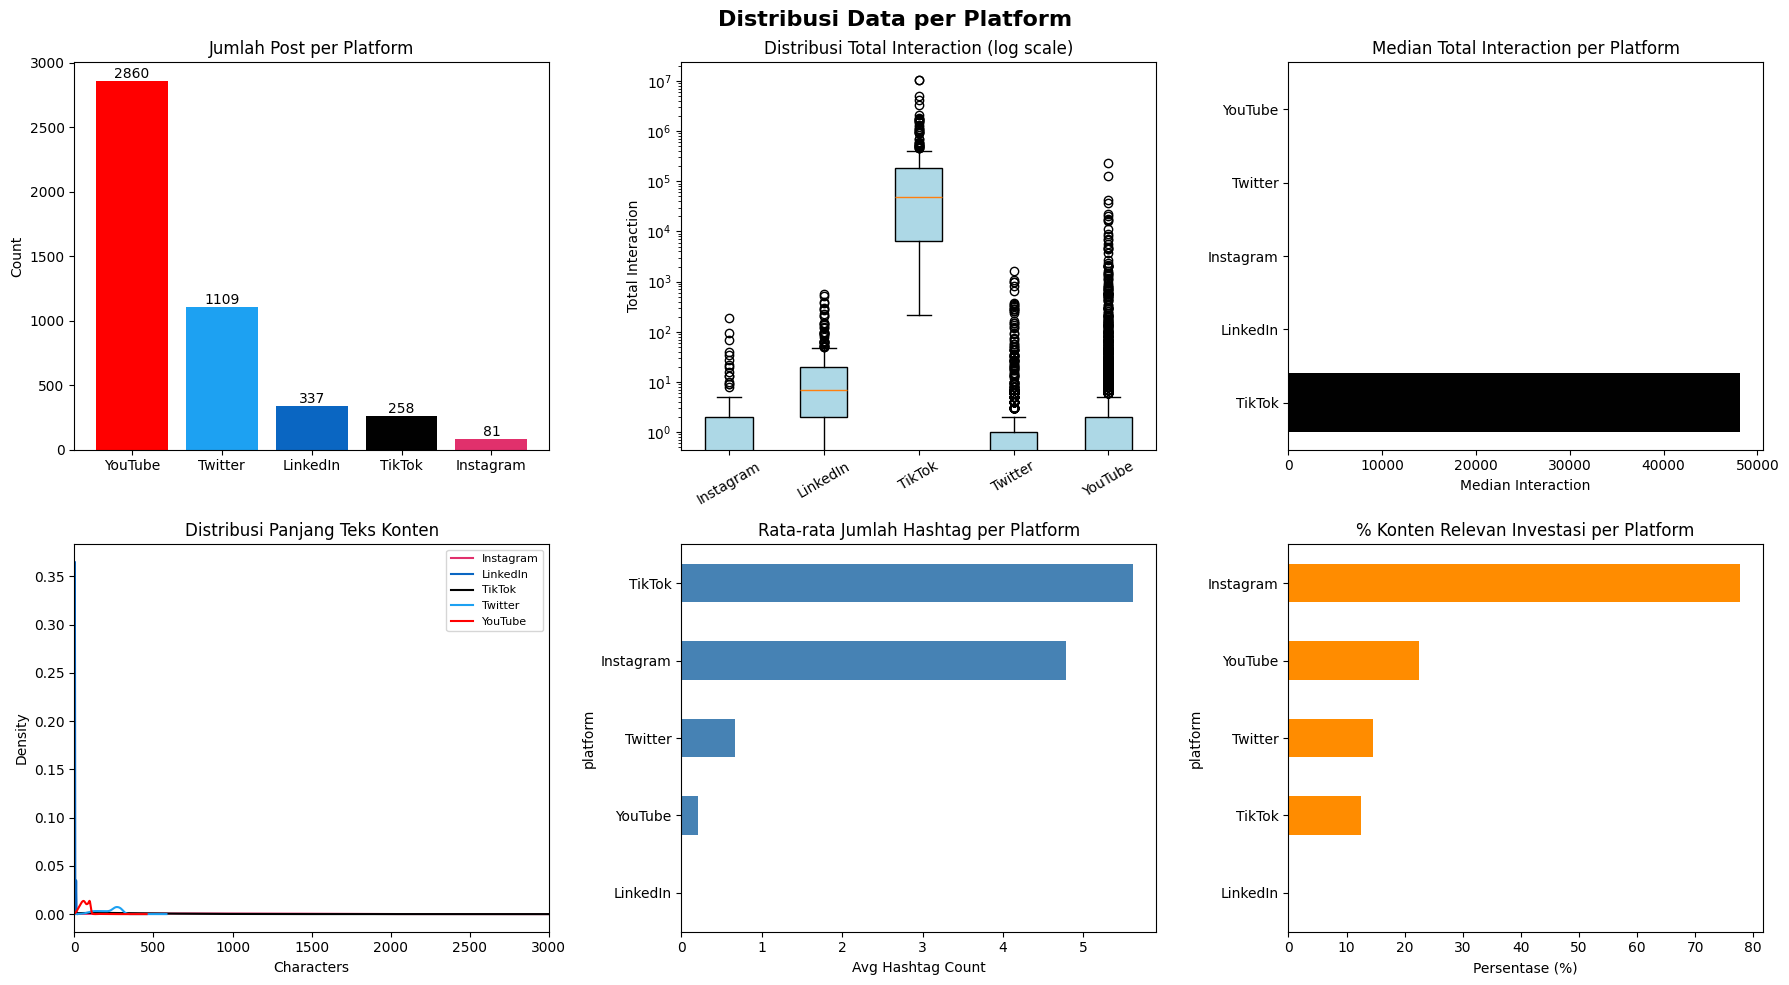

In [ ]:
#16
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle("Distribusi Data per Platform", fontsize=16, fontweight="bold")

platforms = df_all["platform"].unique()

# Record count
ax = axes[0, 0]
counts = df_all["platform"].value_counts()
bars = ax.bar(counts.index, counts.values,
              color=[PLATFORM_COLORS.get(p, "gray") for p in counts.index])
ax.set_title("Jumlah Post per Platform")
ax.set_ylabel("Count")
for bar, val in zip(bars, counts.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
            str(val), ha="center", va="bottom", fontsize=10)

# Total interaction boxplot (log scale)
ax = axes[0, 1]
data_box = [df_all[df_all["platform"]==p]["total_interaction"].dropna()
            for p in platforms]
ax.boxplot(data_box, labels=platforms, patch_artist=True,
           boxprops=dict(facecolor="lightblue"))
ax.set_yscale("log")
ax.set_title("Distribusi Total Interaction (log scale)")
ax.set_ylabel("Total Interaction")
ax.tick_params(axis="x", rotation=30)

# Engagement by platform (median)
ax = axes[0, 2]
med_eng = df_all.groupby("platform")["total_interaction"].median().sort_values(ascending=False)
ax.barh(med_eng.index, med_eng.values,
        color=[PLATFORM_COLORS.get(p, "gray") for p in med_eng.index])
ax.set_title("Median Total Interaction per Platform")
ax.set_xlabel("Median Interaction")

# Text length distribution
ax = axes[1, 0]
for p in platforms:
    subset = df_all[df_all["platform"]==p]["text_length"].dropna()
    subset.plot.kde(ax=ax, label=p, color=PLATFORM_COLORS.get(p, "gray"))
ax.set_title("Distribusi Panjang Teks Konten")
ax.set_xlabel("Characters")
ax.set_xlim(0, 3000)
ax.legend(fontsize=8)

# Hashtag count distribution
ax = axes[1, 1]
df_all.groupby("platform")["hashtag_count"].mean().sort_values().plot(
    kind="barh", ax=ax, color="steelblue")
ax.set_title("Rata-rata Jumlah Hashtag per Platform")
ax.set_xlabel("Avg Hashtag Count")

# Investment content proportion
ax = axes[1, 2]
inv_prop = df_all.groupby("platform")["is_investment_content"].mean() * 100
inv_prop.sort_values().plot(kind="barh", ax=ax, color="darkorange")
ax.set_title("% Konten Relevan Investasi per Platform")
ax.set_xlabel("Persentase (%)")

plt.tight_layout()
plt.savefig("01_eda_per_platform.png", dpi=150, bbox_inches="tight")
plt.show()

## **EDA: Time Series Posting Activity**

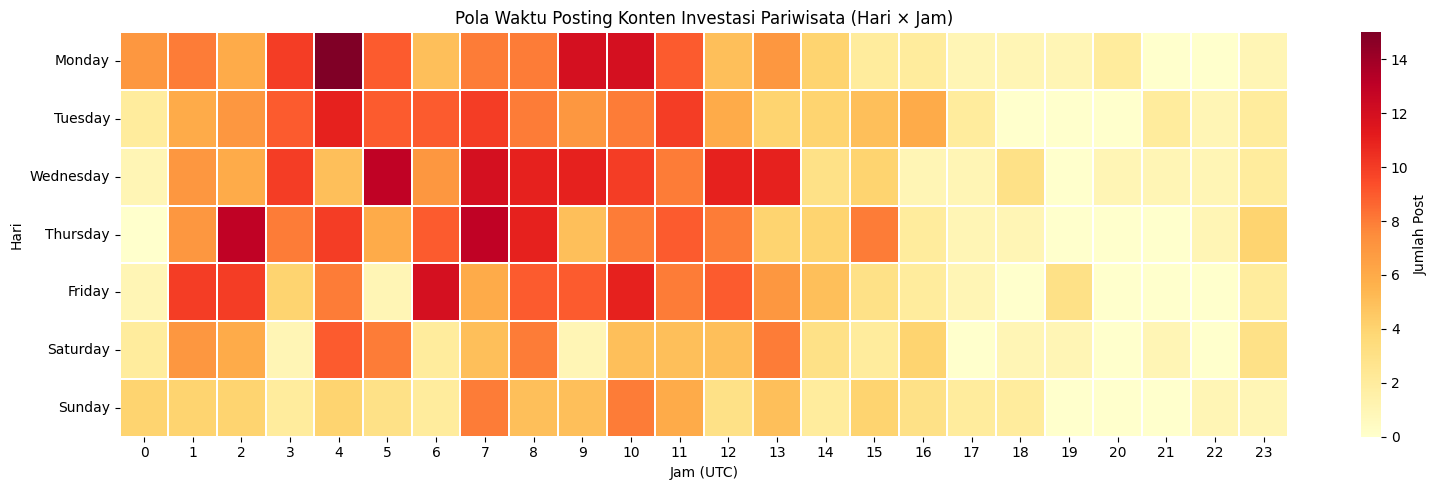

In [ ]:
#18
# Filter hanya yang ada timestamp valid
df_ts = df_all.dropna(subset=["timestamp"]).copy()
df_ts["date"] = df_ts["timestamp"].dt.date

# Volume posting per hari per platform
daily_vol = (df_ts.groupby(["date","platform"])
             .size()
             .reset_index(name="count"))

fig = px.line(
    daily_vol, x="date", y="count", color="platform",
    color_discrete_map=PLATFORM_COLORS,
    title="Volume Posting Harian per Platform",
    labels={"date":"Tanggal","count":"Jumlah Post","platform":"Platform"}
)
fig.update_layout(height=400)
fig.show()

# Heatmap: jam vs hari (kapan konten investment paling banyak diposting)
df_inv = df_ts[df_ts["is_investment_content"]==1].copy()
df_inv["hour"] = df_inv["timestamp"].dt.hour
df_inv["dow"]  = df_inv["timestamp"].dt.day_name()

dow_order = ["Monday","Tuesday","Wednesday","Thursday","Friday","Saturday","Sunday"]
heatmap_data = (df_inv.groupby(["dow","hour"])
                .size()
                .unstack(fill_value=0)
                .reindex(dow_order))

plt.figure(figsize=(16, 5))
sns.heatmap(heatmap_data, cmap="YlOrRd", linewidths=0.3,
            cbar_kws={"label":"Jumlah Post"})
plt.title("Pola Waktu Posting Konten Investasi Pariwisata (Hari × Jam)")
plt.xlabel("Jam (UTC)")
plt.ylabel("Hari")
plt.tight_layout()
plt.savefig("02_posting_heatmap.png", dpi=150)
plt.show()

## **Cross-Platform Engagement Comparison**

In [ ]:
#20
# ── Kruskal-Wallis: apakah ada perbedaan signifikan antar platform ─────────────
groups = [df_all[df_all["platform"]==p]["total_interaction"].dropna().values
          for p in df_all["platform"].unique()]

stat, pval = kruskal(*groups)
print(f"Kruskal-Wallis H={stat:.2f}, p={pval:.4f}")
print("→ Ada perbedaan signifikan" if pval < 0.05 else "→ Tidak ada perbedaan signifikan")

# ── Pairwise Mann-Whitney (post-hoc) ─────────────────────────────────────────
from itertools import combinations

platforms_list = df_all["platform"].unique().tolist()
results = []
for p1, p2 in combinations(platforms_list, 2):
    g1 = df_all[df_all["platform"]==p1]["total_interaction"].dropna().values
    g2 = df_all[df_all["platform"]==p2]["total_interaction"].dropna().values
    if len(g1) > 0 and len(g2) > 0:
        u, p = mannwhitneyu(g1, g2, alternative="two-sided")
        results.append({"Platform A": p1, "Platform B": p2, "U": u, "p-value": p,
                        "Signifikan": "✅" if p < 0.05 else "❌"})

df_pairwise = pd.DataFrame(results)
print("\nPairwise Mann-Whitney U Test:")
display(df_pairwise)

# ── Violin plot engagement per platform ──────────────────────────────────────
fig = px.violin(
    df_all[df_all["total_interaction"] > 0],
    x="platform", y="total_interaction",
    color="platform", color_discrete_map=PLATFORM_COLORS,
    log_y=True, box=True, points="outliers",
    title="Distribusi Engagement per Platform (log scale)"
)
fig.show()

Kruskal-Wallis H=1319.16, p=0.0000
→ Ada perbedaan signifikan

Pairwise Mann-Whitney U Test:


,Platform A,Platform B,U,p-value,Signifikan
0,Instagram,LinkedIn,5666.5,2.260014e-16,✅
1,Instagram,TikTok,0.0,4.116612e-42,✅
2,Instagram,Twitter,43511.0,6.100956e-01,❌
3,Instagram,YouTube,123339.5,2.226531e-01,❌
4,LinkedIn,TikTok,25.0,4.001096e-97,✅
5,LinkedIn,Twitter,312134.5,2.953022e-84,✅
6,LinkedIn,YouTube,780269.5,1.386148e-102,✅
7,TikTok,Twitter,286021.0,4.737312e-150,✅
8,TikTok,YouTube,735523.0,7.621929e-208,✅
9,Twitter,YouTube,1769357.0,3.735877e-11,✅


## **Hashtag Analysis**

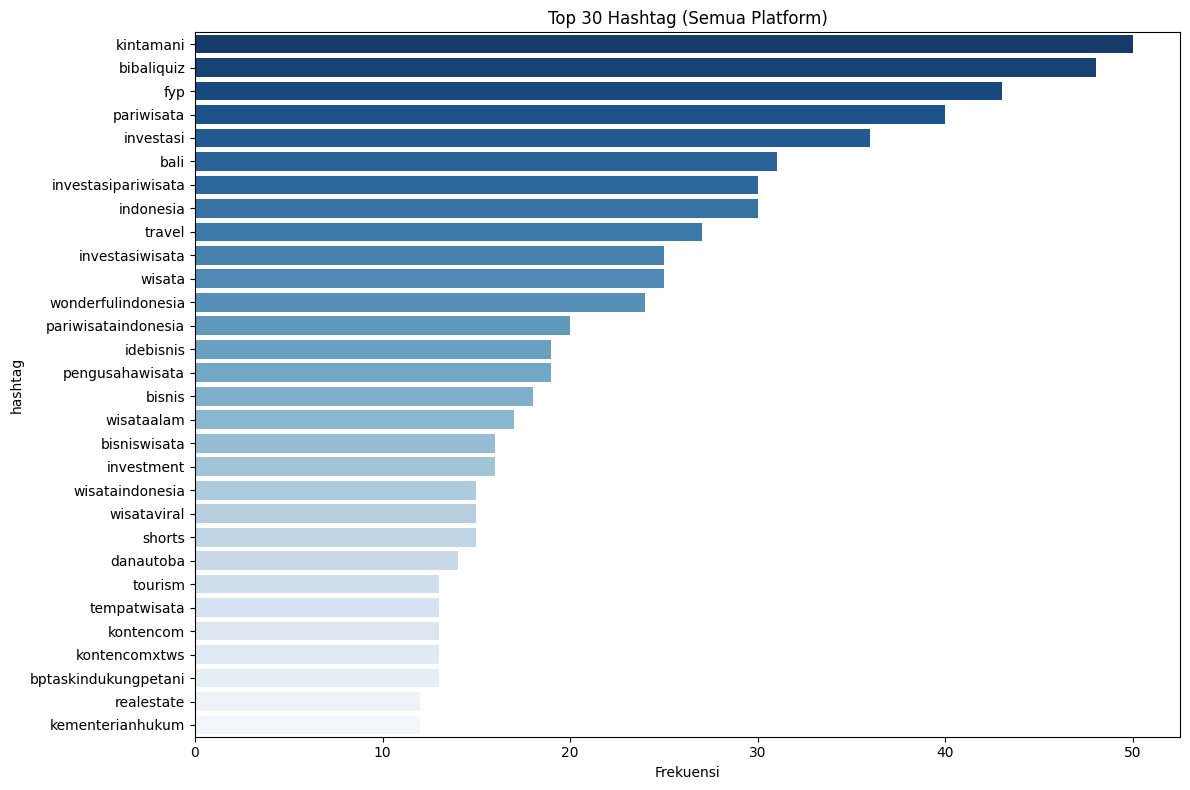


Top 10 Hashtag — Instagram
  #investasiwisata                   24
  #investasipariwisata               23
  #bisniswaterpark                    7
  #investasiproperti                  6
  #wonderfulindonesia                 6
  #pariwisataindonesia                5
  #kolamrenangumum                    5
  #kolamrenangresort                  5
  #waterboomresort                    5
  #labuanbajo                         4

Top 10 Hashtag — LinkedIn

Top 10 Hashtag — TikTok
  #fyp                               42
  #pariwisata                        23
  #wisata                            21
  #travel                            21
  #idebisnis                         19
  #pengusahawisata                   19
  #bisnis                            16
  #wonderfulindonesia                15
  #wisataviral                       15
  #wisataalam                        15

Top 10 Hashtag — Twitter
  #kintamani                         48
  #bibaliquiz                        48
  #investasi  

In [ ]:
#22
from collections import Counter

# Explode hashtag list → satu baris per hashtag
df_htag = df_all[["platform","hashtags","total_interaction","is_investment_content"]].copy()
df_htag = df_htag.explode("hashtags").dropna(subset=["hashtags"])
df_htag["hashtags"] = df_htag["hashtags"].str.lower().str.strip()
df_htag = df_htag[df_htag["hashtags"] != ""]

# ── Top 30 Hashtag Global ──────────────────────────────────
top_global = Counter(df_htag["hashtags"]).most_common(30)
ht_df = pd.DataFrame(top_global, columns=["hashtag","count"])

plt.figure(figsize=(12, 8))
sns.barplot(data=ht_df, y="hashtag", x="count", palette="Blues_r")
plt.title("Top 30 Hashtag (Semua Platform)")
plt.xlabel("Frekuensi")
plt.tight_layout()
plt.savefig("03_top_hashtags.png", dpi=150)
plt.show()

# ── Hashtag vs Engagement (scatter) ───────────────────────────
htag_eng = (df_htag.groupby("hashtags")
            .agg(freq=("hashtags","count"),
                 avg_interaction=("total_interaction","mean"))
            .reset_index()
            .query("freq >= 3"))   # filter rare hashtags

fig = px.scatter(
    htag_eng.nlargest(80, "freq"),
    x="freq", y="avg_interaction",
    text="hashtags", size="freq",
    title="Hashtag: Frekuensi vs Rata-rata Engagement",
    labels={"freq":"Frekuensi Pemakaian","avg_interaction":"Avg Total Interaction"}
)
fig.update_traces(textposition="top center", textfont_size=9)
fig.show()

# ── Top hashtag per platform ───────────────────────
for plat in df_all["platform"].unique():
    subset = df_htag[df_htag["platform"]==plat]
    top10  = Counter(subset["hashtags"]).most_common(10)
    print(f"\n{'='*40}")
    print(f"Top 10 Hashtag — {plat}")
    print('='*40)
    for ht, cnt in top10:
        print(f"  #{ht:<30} {cnt:>5}")

## **BERTopic: Topic Modeling Konten Investasi**

In [ ]:
#24
# ── Prep teks ─────────────────────────────────────────────────────────────────
def clean_text(text):
    if not isinstance(text, str):
        return ""
    text = re.sub(r"http\S+", "", text)          # hapus URL
    text = re.sub(r"#\w+", "", text)             # hapus hashtag
    text = re.sub(r"@\w+", "", text)             # hapus mention
    text = re.sub(r"[^\w\s]", " ", text)         # hapus punctuation
    text = re.sub(r"\s+", " ", text).strip()
    tokens = [w for w in text.lower().split() if w not in STOPWORDS_ALL and len(w) > 2]
    return " ".join(tokens)

df_all["text_clean"] = df_all["text"].apply(clean_text)

# Filter konten relevan investasi saja untuk topic modeling
docs = df_all[df_all["is_investment_content"]==1]["text_clean"].tolist()
doc_indices = df_all[df_all["is_investment_content"]==1].index.tolist()

print(f"Jumlah dokumen untuk topic modeling: {len(docs)}")

# ── BERTopic ──────────────────────────────────────────────────────────────────
# Gunakan multilingual sentence transformer
embedding_model = SentenceTransformer("paraphrase-multilingual-MiniLM-L12-v2")

vectorizer = CountVectorizer(
    stop_words=list(STOPWORDS_ALL),
    min_df=2,
    ngram_range=(1, 2)
)

topic_model = BERTopic(
    embedding_model=embedding_model,
    vectorizer_model=vectorizer,
    language="multilingual",
    nr_topics="auto",
    min_topic_size=3,
    verbose=True
)

topics, probs = topic_model.fit_transform(docs)
df_all.loc[doc_indices, "bertopic_topic"] = topics

# ── Visualisasi Topics ────────────────────────────────────────────────────────
print("\nTop Topics:")
display(topic_model.get_topic_info().head(15))

fig_bar = topic_model.visualize_barchart(top_n_topics=10, n_words=8)
fig_bar.show()

fig_map = topic_model.visualize_topics()
fig_map.show()

# ── Topic per Platform ────────────────────────────────────────────────────────
topic_platform = (df_all[df_all["bertopic_topic"].notna()]
                  .groupby(["platform","bertopic_topic"])
                  .size()
                  .reset_index(name="count"))
fig = px.bar(topic_platform, x="bertopic_topic", y="count",
             color="platform", color_discrete_map=PLATFORM_COLORS,
             barmode="stack",
             title="Distribusi Topic per Platform")
fig.show()

Jumlah dokumen untuk topic modeling: 897


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

2026-06-08 01:27:07,649 - BERTopic - Embedding - Transforming documents to embeddings.


Batches:   0%|          | 0/29 [00:00<?, ?it/s]

2026-06-08 01:27:52,924 - BERTopic - Embedding - Completed ✓
2026-06-08 01:27:52,926 - BERTopic - Dimensionality - Fitting the dimensionality reduction algorithm
2026-06-08 01:27:55,425 - BERTopic - Dimensionality - Completed ✓
2026-06-08 01:27:55,427 - BERTopic - Cluster - Start clustering the reduced embeddings
2026-06-08 01:27:55,468 - BERTopic - Cluster - Completed ✓
2026-06-08 01:27:55,470 - BERTopic - Representation - Extracting topics using c-TF-IDF for topic reduction.
2026-06-08 01:27:55,560 - BERTopic - Representation - Completed ✓
2026-06-08 01:27:55,562 - BERTopic - Topic reduction - Reducing number of topics
2026-06-08 01:27:55,580 - BERTopic - Representation - Fine-tuning topics using representation models.
2026-06-08 01:27:55,635 - BERTopic - Representation - Completed ✓
2026-06-08 01:27:55,638 - BERTopic - Topic reduction - Reduced number of topics from 60 to 11



Top Topics:


,Topic,Count,Name,Representation,Representative_Docs
0,-1,175,-1_bali_villa_investment_investasi,"[bali, villa, investment, investasi, resort, p...",[petitenget investment villa bali indonesia ma...
1,0,647,0_investment_bali_investasi_property,"[investment, bali, investasi, property, pariwi...",[spending bali earning fractional property inv...
2,1,14,1_glamping_elegant_term_worth,"[glamping, elegant, term, worth, umalas, live,...","[glamping, glamping, elegant umalas retreat]"
3,2,12,2_ðÿœ_canggu_bali ðÿœ_canggu bali,"[ðÿœ, canggu, bali ðÿœ, canggu bali, bayuh, ðÿ...",[biombo architects masterpiece canggu bali ðÿœ...
4,3,10,3_waterpark_desain_wahana_aman,"[waterpark, desain, wahana, aman, kolam, lengk...",[bangun wahana waterpark kekinian desain unik ...
5,4,8,4_hills_puncak bogor_bogor_puncak,"[hills, puncak bogor, bogor, puncak, coco, coc...","[zoya hills puncak bogor, zoya hills puncak bo..."
6,5,8,5_ocean_real estate_estate_real,"[ocean, real estate, estate, real, estate bali...","[inst ocean real estate, inst ocean real estat..."
7,6,7,6_menteri_bertemu_menteri investasi_gudang,"[menteri, bertemu, menteri investasi, gudang, ...",[bertemu menteri investasi uae mohamed hassan ...
8,7,6,7_meets_serenity_heart_family,"[meets, serenity, heart, family, baliâœ, elega...","[serenity meets charm, serenity meets charm, m..."
9,8,5,8_gubernur_program_politik_pak,"[gubernur, program, politik, pak, produktif, p...",[pertemuan sangat bersahabat produktif gubernu...


### BERTopic Model Initialization

The `topic_model` object is created by fitting a BERTopic model to your cleaned text data. This process involves using a sentence transformer for embeddings and a `CountVectorizer` for topic representation. The code below from cell `SBKvUCZhEmJY` defines and trains the `topic_model`.

In [ ]:
# This code snippet is from cell SBKvUCZhEmJY and defines the topic_model.
# It has already been executed in your current session.

# Prepare documents for topic modeling (assuming df_all, is_investment_content, and clean_text are defined)
docs = df_all[df_all["is_investment_content"]==1]["text_clean"].tolist()
doc_indices = df_all[df_all["is_investment_content"]==1].index.tolist()

# Initialize embedding model and vectorizer
embedding_model = SentenceTransformer("paraphrase-multilingual-MiniLM-L12-v2")

vectorizer = CountVectorizer(
    stop_words=list(STOPWORDS_ALL),
    min_df=2,
    ngram_range=(1, 2)
)

# Create and fit the BERTopic model
topic_model = BERTopic(
    embedding_model=embedding_model,
    vectorizer_model=vectorizer,
    language="multilingual",
    nr_topics="auto",
    min_topic_size=3,
    verbose=True
)

topics, probs = topic_model.fit_transform(docs)
df_all.loc[doc_indices, "bertopic_topic"] = topics

print("✅ `topic_model` has been initialized and fitted.")

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

2026-06-08 01:28:01,922 - BERTopic - Embedding - Transforming documents to embeddings.


Batches:   0%|          | 0/29 [00:00<?, ?it/s]

2026-06-08 01:28:30,718 - BERTopic - Embedding - Completed ✓
2026-06-08 01:28:30,720 - BERTopic - Dimensionality - Fitting the dimensionality reduction algorithm
2026-06-08 01:28:36,436 - BERTopic - Dimensionality - Completed ✓
2026-06-08 01:28:36,438 - BERTopic - Cluster - Start clustering the reduced embeddings
2026-06-08 01:28:36,467 - BERTopic - Cluster - Completed ✓
2026-06-08 01:28:36,468 - BERTopic - Representation - Extracting topics using c-TF-IDF for topic reduction.
2026-06-08 01:28:36,551 - BERTopic - Representation - Completed ✓
2026-06-08 01:28:36,552 - BERTopic - Topic reduction - Reducing number of topics
2026-06-08 01:28:36,574 - BERTopic - Representation - Fine-tuning topics using representation models.
2026-06-08 01:28:36,669 - BERTopic - Representation - Completed ✓
2026-06-08 01:28:36,672 - BERTopic - Topic reduction - Reduced number of topics from 68 to 45


✅ `topic_model` has been initialized and fitted.


### Word Clouds for Top BERTopic Topics

Generating a word cloud for the whole BERTopic model...


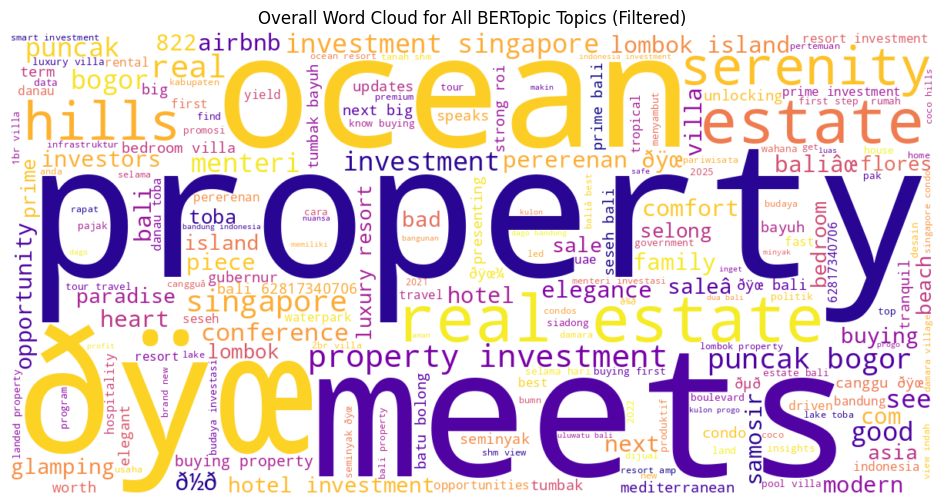

✅ Overall word cloud generated.


In [ ]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt
import re # Added for regex filtering

try:
    # Attempt to access topic_model to check if it's defined
    _ = topic_model.get_topic_info()
except NameError:
    print("Error: 'topic_model' is not defined. Please ensure the BERTopic analysis cell (the one containing `topic_model = BERTopic(...)`) has been run successfully before executing this cell.")
else:
    # Get topic information
    topic_info = topic_model.get_topic_info()

    # Filter out the -1 topic (outliers)
    valid_topics_info = topic_info[topic_info['Topic'] != -1]

    # === Generate a word cloud for the whole topic (all topics combined) ===
    print("Generating a word cloud for the whole BERTopic model...")
    all_topic_words_scores = {}

    # Define dirty words to filter out (exact match)
    # Added '6' as a standalone word, and '6 crossed' for multi-word phrases.
    dirty_words = {"1/2", "y", "oe", "6", "crossed", "amp", "6 crossed"}

    # Regex for detecting Greek characters
    greek_char_pattern = re.compile(r'[\u0370-\u03ff\u1f00-\u1fff]')

    for topic_id in valid_topics_info['Topic']:
        words_scores = topic_model.get_topic(topic_id)
        for word, score in words_scores:
            # Aggregate scores for words that might appear in multiple topics
            all_topic_words_scores[word] = all_topic_words_scores.get(word, 0) + score

    if all_topic_words_scores:
        # Filter out dirty words and words containing Greek characters from the aggregated scores
        filtered_words_scores = {
            word: score for word, score in all_topic_words_scores.items()
            if word not in dirty_words and not greek_char_pattern.search(word)
        }

        wordcloud_whole = WordCloud(
            width=1200, height=600, background_color='white',
            colormap='plasma',
            min_font_size=10
        ).generate_from_frequencies(filtered_words_scores)

        plt.figure(figsize=(12, 6))
        plt.imshow(wordcloud_whole, interpolation='bilinear')
        plt.axis('off')
        plt.title("Overall Word Cloud for All BERTopic Topics (Filtered)")
        plt.show()
        print("✅ Overall word cloud generated.")
    else:
        print("No words found to generate an overall word cloud.")

To see which variables are currently defined in your Colab environment, you can use the following commands:

In [ ]:
# 1. Using the %whos magic command (most comprehensive)
# This command lists all variables, their types, and their sizes.
%whos

Variable                   Type                          Data/Info
------------------------------------------------------------------
BASE_PATH                  str                           /content/drive/MyDrive/SDC
BERTopic                   type                          <class 'bertopic._bertopic.BERTopic'>
CountVectorizer            type                          <class 'sklearn.feature_e<...>on.text.CountVectorizer'>
Counter                    type                          <class 'collections.Counter'>
DESTINASI_KEYWORD_MAP      dict                          n=13
DEST_TO_PROVINSI           dict                          n=13
FILES                      dict                          n=5
FRAMES                     dict                          n=6
ID_KEYWORDS                list                          n=10
INV_KEYWORDS               list                          n=23
KUADRAN_COLORS             dict                          n=4
LAKIN_INVESTASI            DataFrame                    

In [ ]:
# 2. Using the %who magic command (simpler list)
# This command lists only the names of all defined variables.
%who

BASE_PATH	 BERTopic	 CountVectorizer	 Counter	 DESTINASI_KEYWORD_MAP	 DEST_TO_PROVINSI	 FILES	 FRAMES	 ID_KEYWORDS	 
INV_KEYWORDS	 KUADRAN_COLORS	 LAKIN_INVESTASI	 PLATFORM_COLORS	 STOPWORDS_ALL	 SW_EN	 SW_ID	 SentenceTransformer	 TARGET_CAPAIAN	 
WordCloud	 all_topic_words_scores	 auth	 ax	 axes	 bali_dominant	 bar	 bars	 categories	 
classify_capaian	 clean_text	 cnt	 col	 combinations	 corr	 counts	 create_scatterplotmatrix	 creds	 
d	 daily_vol	 data_box	 dest_eng	 dest_platform	 detect_lang	 df_all	 df_dest	 df_focus	 
df_geo_active	 df_htag	 df_inv	 df_li_raw	 df_map_lakin	 df_melt	 df_pairwise	 df_pattern	 df_pattern_ts	 
df_trends	 df_ts	 df_tw_raw	 df_yt	 df_yt_raw	 digital_presence	 dims	 dirty_words	 doc_indices	 
docs	 dominant_query	 dow_order	 drive	 embedding_model	 eng_hour	 eng_htag	 eng_len	 feature_cols	 
fig	 fig2	 fig3	 fig_bar	 fig_geo	 fig_map	 fig_ratio	 filtered_words_scores	 frame	 
frame_cols	 frame_summary	 g1	 g2	 gap_df	 gc	 geo_li	 geo_tw	 get_as_datafram

In [ ]:
# 3. Using the built-in dir() function
# This function returns a list of names in the current scope.
print(dir())

['BASE_PATH', 'BERTopic', 'CountVectorizer', 'Counter', 'DESTINASI_KEYWORD_MAP', 'DEST_TO_PROVINSI', 'FILES', 'FRAMES', 'ID_KEYWORDS', 'INV_KEYWORDS', 'In', 'KUADRAN_COLORS', 'LAKIN_INVESTASI', 'Out', 'PLATFORM_COLORS', 'STOPWORDS_ALL', 'SW_EN', 'SW_ID', 'SentenceTransformer', 'TARGET_CAPAIAN', 'WordCloud', '_', '__', '___', '__builtin__', '__builtins__', '__doc__', '__loader__', '__name__', '__package__', '__spec__', '_dh', '_exit_code', '_i', '_i1', '_i10', '_i11', '_i12', '_i13', '_i14', '_i15', '_i16', '_i17', '_i18', '_i19', '_i2', '_i20', '_i21', '_i22', '_i23', '_i24', '_i25', '_i26', '_i27', '_i28', '_i29', '_i3', '_i30', '_i31', '_i32', '_i33', '_i34', '_i35', '_i36', '_i37', '_i38', '_i39', '_i4', '_i40', '_i41', '_i42', '_i43', '_i44', '_i45', '_i46', '_i47', '_i48', '_i49', '_i5', '_i50', '_i51', '_i52', '_i53', '_i54', '_i55', '_i6', '_i7', '_i8', '_i9', '_ih', '_ii', '_iii', '_oh', 'all_topic_words_scores', 'auth', 'ax', 'axes', 'bali_dominant', 'bar', 'bars', 'categories

### Word Clouds for Top BERTopic Topics

**Important:** Ensure you have run the BERTopic analysis cell (`SBKvUCZhEmJY`) *before* executing this cell. The `topic_model` object must be defined for this code to work.

Generating word clouds for the top 5 topics...


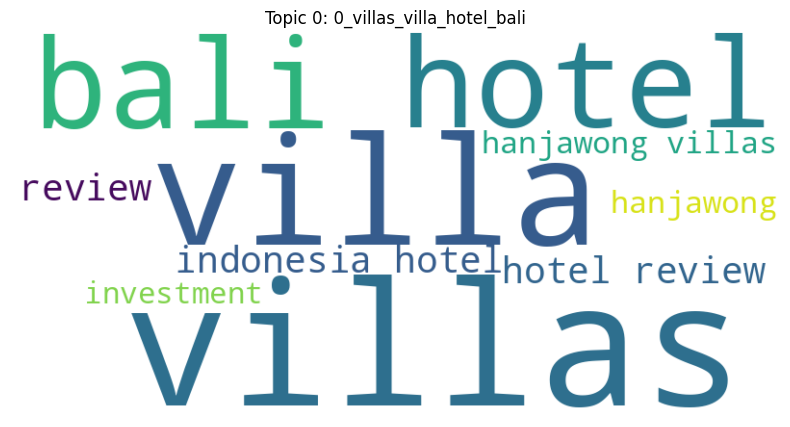

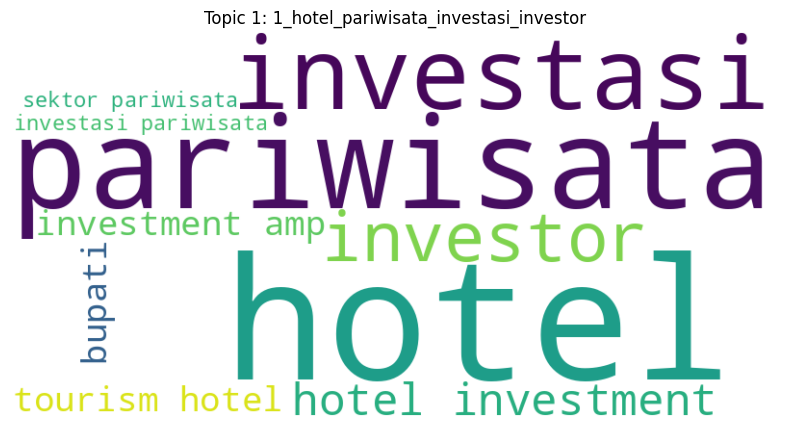

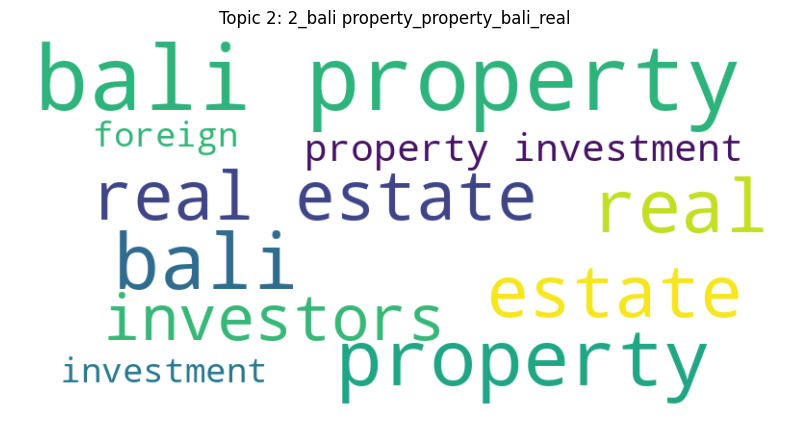

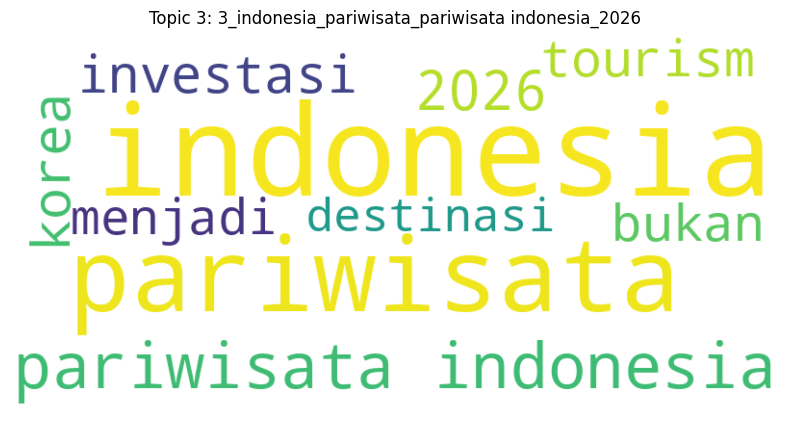

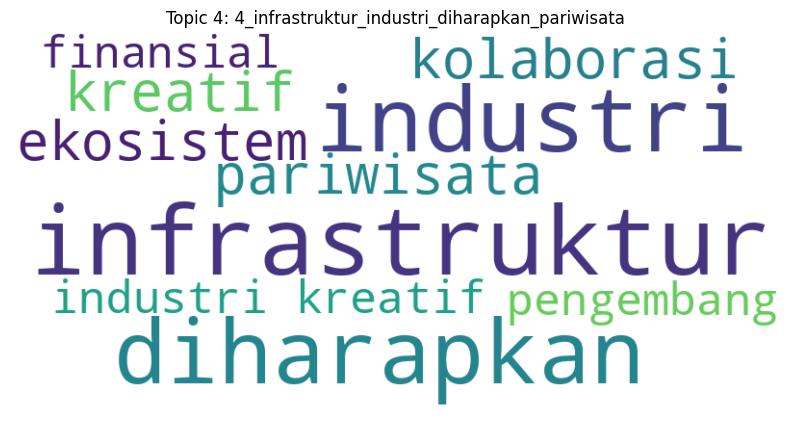

✅ Word clouds generated.


In [ ]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

try:
    # Attempt to access topic_model to check if it's defined
    _ = topic_model.get_topic_info()
except NameError:
    print("Error: 'topic_model' is not defined. Please ensure the BERTopic analysis cell (the one containing `topic_model = BERTopic(...)`) has been run successfully before executing this cell.")
except Exception as e:
    print(f"An unexpected error occurred while accessing topic_model: {e}")
else:
    # Get topic information
    topic_info = topic_model.get_topic_info()

    # Filter out the -1 topic (outliers) and get the top N topics
    n_top_topics = 5 # You can adjust this number
    # Ensure topic_info is not empty after filtering and has enough topics
    if not topic_info[topic_info['Topic'] != -1].empty:
        top_topics_ids = topic_info[topic_info['Topic'] != -1]['Topic'].head(n_top_topics).tolist()
    else:
        print("No topics found after filtering. Please check your BERTopic analysis.")
        top_topics_ids = []

    if top_topics_ids:
        # Generate a word cloud for each top topic
        print(f"Generating word clouds for the top {len(top_topics_ids)} topics...")
        for topic_id in top_topics_ids:
            # Get the words and their scores for the current topic
            words_scores = topic_model.get_topic(topic_id)
            if words_scores:
                wordcloud_data = {word: score for word, score in words_scores}

                # Create the word cloud
                wordcloud = WordCloud(
                    width=800, height=400, background_color='white',
                    colormap='viridis',  # Choose a colormap for better visualization
                    min_font_size=10
                ).generate_from_frequencies(wordcloud_data)

                # Display the word cloud
                plt.figure(figsize=(10, 5))
                plt.imshow(wordcloud, interpolation='bilinear')
                plt.axis('off')
                topic_name = topic_info[topic_info['Topic']==topic_id]['Name'].iloc[0] if not topic_info[topic_info['Topic']==topic_id].empty else f"Topic {topic_id}"
                plt.title(f"Topic {topic_id}: {topic_name}")
                plt.show()
            else:
                print(f"No words found for Topic {topic_id}.")

        print("✅ Word clouds generated.")
    else:
        print("No top topics to generate word clouds for.")

In [ ]:
# Using the %whos magic command to list all variables in memory
%whos

Variable                   Type                          Data/Info
------------------------------------------------------------------
BASE_PATH                  str                           /content/drive/MyDrive/SDC
BERTopic                   type                          <class 'bertopic._bertopic.BERTopic'>
CountVectorizer            type                          <class 'sklearn.feature_e<...>on.text.CountVectorizer'>
Counter                    type                          <class 'collections.Counter'>
DESTINASI_KEYWORD_MAP      dict                          n=13
DEST_TO_PROVINSI           dict                          n=13
FILES                      dict                          n=5
FRAMES                     dict                          n=6
ID_KEYWORDS                list                          n=10
INV_KEYWORDS               list                          n=23
KUADRAN_COLORS             dict                          n=4
LAKIN_INVESTASI            DataFrame                    

The `%whos` command is generally the most informative for inspecting the current state of your notebook's memory.

## **Sentiment & Framing Analysis**

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]


Frame prevalence per platform (konten investasi):


platform,Instagram,TikTok,Twitter,YouTube
frame_roi,8,2,9,60
frame_infrastruktur,23,11,49,7
frame_regulasi,5,2,10,2
frame_destinasi,32,10,34,352
frame_sustainability,13,4,8,4
frame_kemitraan,4,5,21,1


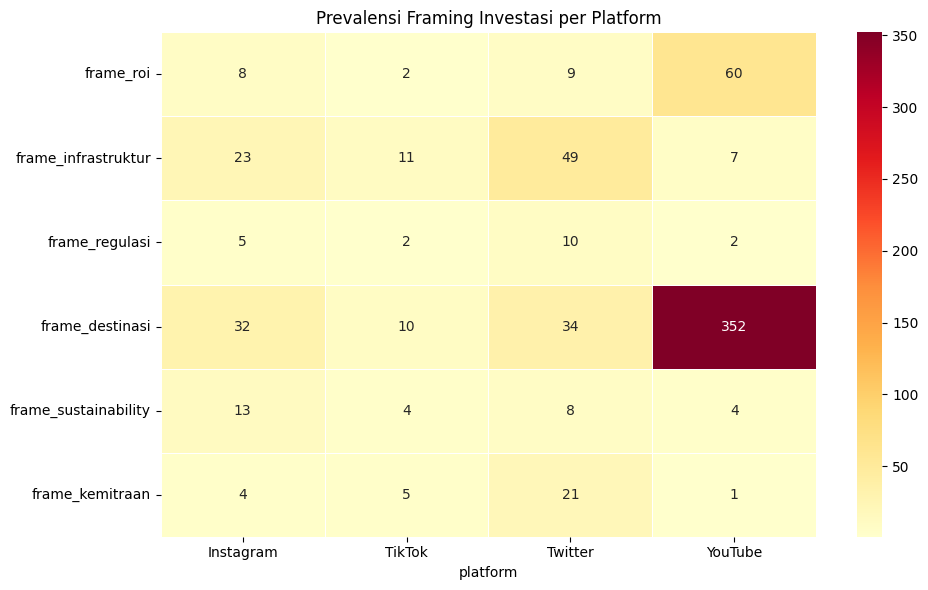

In [ ]:
#26
# ── Multilingual sentiment (IndoBERT / mBERT) ─────────────────────────────────
# Opsi 1: pakai model multilingual ringan
sentiment_pipe = hf_pipeline(
    "sentiment-analysis",
    model="cardiffnlp/twitter-xlm-roberta-base-sentiment",
    tokenizer="cardiffnlp/twitter-xlm-roberta-base-sentiment",
    max_length=512,
    truncation=True,
    device=-1   # CPU; ganti ke 0 kalau pakai GPU
)

def get_sentiment(text):
    if not isinstance(text, str) or len(text.strip()) < 5:
        return "neutral", 0.0
    try:
        result = sentiment_pipe(text[:512])[0]
        return result["label"].lower(), round(result["score"], 4)
    except:
        return "neutral", 0.0

# Jalankan hanya pada konten relevan investasi (efisiensi)
inv_mask = df_all["is_investment_content"] == 1
df_all.loc[inv_mask, ["sentiment","sentiment_score"]] = (
    df_all.loc[inv_mask, "text"]
    .apply(lambda x: pd.Series(get_sentiment(x)))
    .values
)

# ── Distribusi Sentimen per Platform ─────────────────────────────────────────
sent_counts = (df_all[inv_mask]
               .groupby(["platform","sentiment"])
               .size()
               .reset_index(name="count"))

fig = px.bar(
    sent_counts, x="platform", y="count",
    color="sentiment",
    color_discrete_map={"positive":"#2ecc71","neutral":"#95a5a6","negative":"#e74c3c"},
    barmode="group",
    title="Distribusi Sentimen Konten Investasi Pariwisata per Platform"
)
fig.show()

# ── Sentimen vs Engagement ────────────────────────────────────────────────────
sent_eng = (df_all[inv_mask]
            .groupby(["platform","sentiment"])["total_interaction"]
            .median()
            .reset_index())

fig2 = px.bar(
    sent_eng, x="sentiment", y="total_interaction",
    color="platform", color_discrete_map=PLATFORM_COLORS,
    barmode="group",
    title="Median Engagement berdasarkan Sentimen Konten"
)
fig2.show()

# ── Framing Analysis: Investment Frame Detection ──────────────────────────────
FRAMES = {
    "ROI / Return"      : ["roi","return","profit","keuntungan","yield","dividen","pendapatan"],
    "Infrastruktur"     : ["infrastruktur","infrastructure","jalan","bandara","pelabuhan","fasilitas"],
    "Regulasi / Kemudahan": ["izin","perizinan","regulasi","kemudahan","kebijakan","hilirisasi","oss"],
    "Destinasi / Lokasi": ["bali","lombok","labuan","ntt","sumba","raja ampat","mandalika","ike"],
    "Sustainability"    : ["sustainable","berkelanjutan","hijau","green","esg","lingkungan"],
    "Kemitraan"         : ["kerjasama","partnership","kolaborasi","b2b","mou","joint"],
}

for frame, kws in FRAMES.items():
    col = f"frame_{frame.split('/')[0].strip().lower().replace(' ','_')}"
    df_all[col] = df_all["text"].fillna("").apply(
        lambda t: int(any(kw in t.lower() for kw in kws))
    )

frame_cols = [c for c in df_all.columns if c.startswith("frame_")]
frame_summary = (df_all[inv_mask][["platform"] + frame_cols]
                 .groupby("platform")
                 .sum()
                 .T)

print("\nFrame prevalence per platform (konten investasi):")
display(frame_summary)

# Heatmap framing
plt.figure(figsize=(10, 6))
sns.heatmap(frame_summary, annot=True, fmt="d", cmap="YlOrRd",
            linewidths=0.5)
plt.title("Prevalensi Framing Investasi per Platform")
plt.tight_layout()
plt.savefig("04_framing_heatmap.png", dpi=150)
plt.show()

## **Geography Analysis (Audience Origin)**

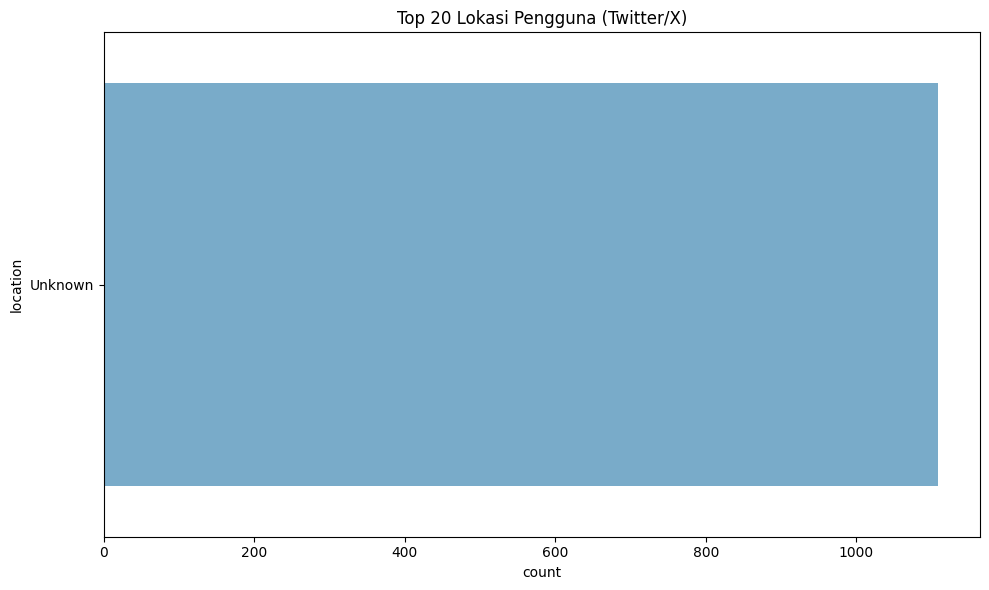


Rata-rata Engagement per Destinasi (YouTube):


,views,likes,comments
destination,,,
unknown,77217.830671,661.041534,31.971246
bali,76977.316854,958.737079,26.451685
labuan bajo,8816.025316,124.202532,9.151899
raja ampat,2826.909091,22.0,1.636364
bromo,2067.205128,17.564103,5.358974
lombok,1090.480226,10.847458,1.107345
danau toba,488.75,6.25,0.75
bintan,421.0,5.0,0.8
batam,373.666667,6.333333,0.333333


In [ ]:
#28
# ── Sumber geografis dari LinkedIn (ada kolom country) ────────────────────────
df_li_raw = load_linkedin(FILES["linkedin"])

geo_li = (df_li_raw["country"].fillna("Unknown")
          .value_counts()
          .reset_index()
          .rename(columns={"country":"country","count":"count"}))

fig = px.choropleth(
    geo_li,
    locations="country",
    locationmode="country names",
    color="count",
    color_continuous_scale="Blues",
    title="Distribusi Negara Asal Konten Investasi Pariwisata (LinkedIn)"
)
fig.show()

# ── Twitter: location field ───────────────────────────────────────────────────
df_tw_raw = load_twitter(FILES["twitter"])
geo_tw = (df_tw_raw["country"].fillna("Unknown")
          .value_counts()
          .head(20)
          .reset_index()
          .rename(columns={"country":"location","count":"count"}))

plt.figure(figsize=(10, 6))
sns.barplot(data=geo_tw, y="location", x="count", palette="Blues_r")
plt.title("Top 20 Lokasi Pengguna (Twitter/X)")
plt.tight_layout()
plt.show()

# ── YouTube: query-based destination proxy ────────────────────────────────────
df_yt_raw = load_youtube(FILES["youtube"])
dest_eng = (df_yt_raw.groupby("destination")[["views","likes","comments"]]
            .mean()
            .round(0)
            .sort_values("views", ascending=False))

print("\nRata-rata Engagement per Destinasi (YouTube):")
display(dest_eng)

fig = px.bar(
    dest_eng.reset_index(),
    x="destination", y="views",
    color="views", color_continuous_scale="Reds",
    title="Rata-rata Views per Destinasi — YouTube"
)
fig.show()

In [ ]:
#29
# ── CELL 27B — Google Trends: Geo Interest Analysis ──────────────────────────
# Sumber: Google Trends export geoMap.csv
# Query: "indonesia investment tourism", "bali investment tourism",
#        "invest in indonesia tourism" | Period: Jun 2025 – Jun 2026

import pandas as pd
import plotly.express as px
import plotly.graph_objects as go

# ── Load & parse ──────────────────────────────────────────────────────────────
df_trends = pd.read_csv(f"{BASE_PATH}/geoMap.csv")
df_trends.columns = ["country", "q_id_invest_tourism", "q_bali_invest", "q_invest_in_id"]

# Konversi persen string ke numerik
for col in ["q_id_invest_tourism", "q_bali_invest", "q_invest_in_id"]:
    df_trends[col] = (df_trends[col]
                      .str.replace("%", "", regex=False)
                      .str.strip()
                      .pipe(pd.to_numeric, errors="coerce"))

# Filter hanya negara yang punya sinyal (minimal 1 query aktif)
df_geo_active = df_trends.dropna(
    subset=["q_id_invest_tourism", "q_bali_invest", "q_invest_in_id"],
    how="all"
).copy()

# Composite interest score: rata-rata bobot sama dari query yang tersedia
df_geo_active["composite_score"] = df_geo_active[
    ["q_id_invest_tourism", "q_bali_invest", "q_invest_in_id"]
].mean(axis=1, skipna=True).round(1)

# Dominant query per negara (query mana yang paling besar)
def dominant_query(row):
    vals = {
        "Indonesia Investment Tourism": row["q_id_invest_tourism"],
        "Bali Investment Tourism"      : row["q_bali_invest"],
        "Invest in Indonesia Tourism"  : row["q_invest_in_id"],
    }
    vals = {k: v for k, v in vals.items() if pd.notna(v)}
    return max(vals, key=vals.get) if vals else "Unknown"

df_geo_active["dominant_query"] = df_geo_active.apply(dominant_query, axis=1)

print(f"Negara dengan search interest: {len(df_geo_active)}")
print(df_geo_active[["country","q_id_invest_tourism","q_bali_invest",
                      "q_invest_in_id","composite_score","dominant_query"]]
      .sort_values("composite_score", ascending=False)
      .to_string(index=False))

# ── Choropleth: Composite Interest Score ─────────────────────────────────────
fig_geo = px.choropleth(
    df_geo_active,
    locations="country",
    locationmode="country names",
    color="composite_score",
    hover_name="country",
    hover_data={
        "q_id_invest_tourism" : True,
        "q_bali_invest"       : True,
        "q_invest_in_id"      : True,
        "dominant_query"      : True,
        "composite_score"     : True,
    },
    color_continuous_scale="Blues",
    title=(
        "<b>Google Trends: Minat Pencarian Investasi Pariwisata Indonesia per Negara</b>"
        "<br><sup>Composite score dari 3 query | Period: Jun 2025 – Jun 2026</sup>"
    ),
    labels={
        "composite_score"     : "Composite Interest Score",
        "q_id_invest_tourism" : "indonesia investment tourism (%)",
        "q_bali_invest"       : "bali investment tourism (%)",
        "q_invest_in_id"      : "invest in indonesia tourism (%)",
    }
)
fig_geo.update_layout(
    geo=dict(showcoastlines=True, projection_type="natural earth"),
    coloraxis_colorbar=dict(title="Interest Score"),
    template="plotly_white"
)
fig_geo.show()

# ── Bar chart: Top negara per query ──────────────────────────────────────────
df_melt = df_geo_active.melt(
    id_vars="country",
    value_vars=["q_id_invest_tourism", "q_bali_invest", "q_invest_in_id"],
    var_name="query", value_name="score"
).dropna(subset=["score"])

df_melt["query"] = df_melt["query"].map({
    "q_id_invest_tourism" : "indonesia investment tourism",
    "q_bali_invest"       : "bali investment tourism",
    "q_invest_in_id"      : "invest in indonesia tourism",
})

# Sort by composite_score
order = df_geo_active.sort_values("composite_score", ascending=True)["country"].tolist()

fig_bar = px.bar(
    df_melt,
    y="country", x="score",
    color="query",
    orientation="h",
    category_orders={"country": order},
    barmode="group",
    title="<b>Search Interest per Negara & Query (Google Trends)</b>",
    labels={"score": "Relative Interest (%)", "country": "Negara", "query": "Query"},
    color_discrete_map={
        "indonesia investment tourism" : "#0A66C2",
        "bali investment tourism"      : "#E1306C",
        "invest in indonesia tourism"  : "#FF6B35",
    },
    template="plotly_white"
)
fig_bar.update_layout(height=500)
fig_bar.show()

# ── Insights ringkas ──────────────────────────────────────────────────────────
top3 = df_geo_active.nlargest(3, "composite_score")[["country","composite_score","dominant_query"]]
print("\n📊 Top 3 Negara berdasarkan Composite Search Interest:")
print(top3.to_string(index=False))

bali_dominant = df_geo_active[df_geo_active["dominant_query"] == "Bali Investment Tourism"]["country"].tolist()
print(f"\n🌏 Negara yang dominant query-nya 'Bali Investment Tourism': {bali_dominant}")
print("→ Implikasi: negara-negara ini lebih terfokus ke Bali, bukan Indonesia secara keseluruhan.")

Negara dengan search interest: 19
       country  q_id_invest_tourism  q_bali_invest  q_invest_in_id  composite_score               dominant_query
          Oman                100.0            NaN             NaN            100.0 Indonesia Investment Tourism
     Singapore                100.0            NaN             NaN            100.0 Indonesia Investment Tourism
         Chile                100.0            NaN             NaN            100.0 Indonesia Investment Tourism
United Kingdom                100.0            NaN             NaN            100.0 Indonesia Investment Tourism
   Switzerland                100.0            NaN             NaN            100.0 Indonesia Investment Tourism
   Philippines                100.0            NaN             NaN            100.0 Indonesia Investment Tourism
     Australia                100.0            NaN             NaN            100.0 Indonesia Investment Tourism
      Thailand                100.0            NaN            


📊 Top 3 Negara berdasarkan Composite Search Interest:
    country  composite_score               dominant_query
       Oman            100.0 Indonesia Investment Tourism
  Singapore            100.0 Indonesia Investment Tourism
Switzerland            100.0 Indonesia Investment Tourism

🌏 Negara yang dominant query-nya 'Bali Investment Tourism': ['Germany']
→ Implikasi: negara-negara ini lebih terfokus ke Bali, bukan Indonesia secara keseluruhan.


## **Content Strategy Pattern Mining**

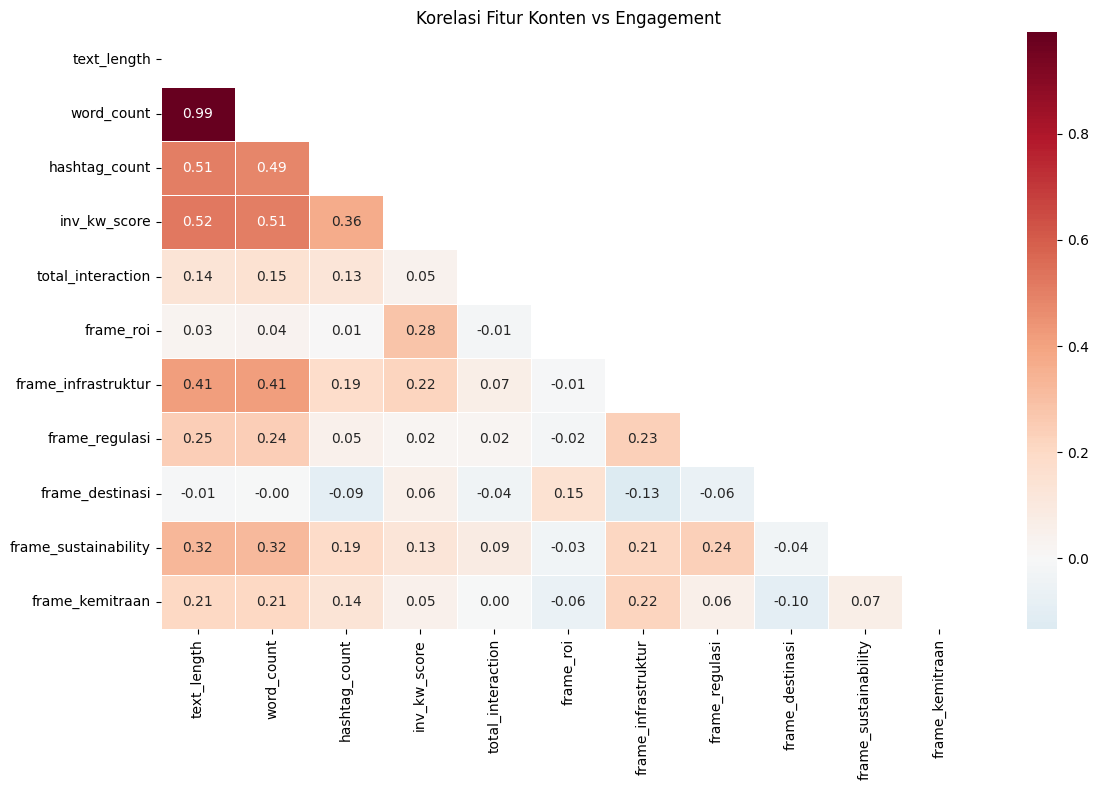

In [ ]:
#31
# ── Feature matrix untuk analisis pola konten ─────────────────────────────────
df_pattern = df_all[inv_mask].copy()

# Binning text length
df_pattern["length_bin"] = pd.cut(
    df_pattern["text_length"],
    bins=[0, 150, 500, 1000, 3000, np.inf],
    labels=["<150","150-500","500-1000","1000-3000",">3000"]
)

# ── Engagement by text length ─────────────────────────────────────────────────
eng_len = (df_pattern.groupby(["platform","length_bin"])["total_interaction"]
           .median()
           .reset_index())

fig = px.bar(
    eng_len, x="length_bin", y="total_interaction",
    color="platform", color_discrete_map=PLATFORM_COLORS,
    barmode="group",
    title="Median Engagement berdasarkan Panjang Konten per Platform",
    category_orders={"length_bin":["<150","150-500","500-1000","1000-3000",">3000"]}
)
fig.show()

# ── Engagement by hashtag count bucket ───────────────────────────────────────
df_pattern["htag_bin"] = pd.cut(
    df_pattern["hashtag_count"],
    bins=[-1, 0, 5, 10, 20, 100],
    labels=["0","1-5","6-10","11-20",">20"]
)

eng_htag = (df_pattern.groupby(["platform","htag_bin"])["total_interaction"]
            .median()
            .reset_index())

fig2 = px.line(
    eng_htag, x="htag_bin", y="total_interaction",
    color="platform", color_discrete_map=PLATFORM_COLORS,
    markers=True,
    title="Median Engagement vs Jumlah Hashtag per Platform"
)
fig2.show()

# ── Posting time vs engagement ────────────────────────────────────────────────
df_pattern_ts = df_pattern.dropna(subset=["hour"])
eng_hour = (df_pattern_ts.groupby(["platform","hour"])["total_interaction"]
            .median()
            .reset_index())

fig3 = px.line(
    eng_hour, x="hour", y="total_interaction",
    color="platform", color_discrete_map=PLATFORM_COLORS,
    markers=True,
    title="Median Engagement berdasarkan Jam Posting"
)
fig3.update_xaxes(dtick=1)
fig3.show()

# ── Correlation matrix: fitur konten vs engagement ───────────────────────────
feature_cols = ["text_length","word_count","hashtag_count","inv_kw_score",
                "total_interaction"] + frame_cols

corr = df_pattern[feature_cols].corr()
plt.figure(figsize=(12, 8))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt=".2f",
            cmap="RdBu_r", center=0, linewidths=0.5)
plt.title("Korelasi Fitur Konten vs Engagement")
plt.tight_layout()
plt.savefig("05_correlation_matrix.png", dpi=150)
plt.show()

## **Investment Signal Scoring & Platform Ranking**

In [ ]:
#33
# ── Normalized scoring per platform ───────────────────────────────────────────
# Dimensi: (1) volume konten, (2) median engagement, (3) % konten relevan,
#           (4) avg investment keyword score, (5) sentiment positif ratio

def normalize(series):
    mn, mx = series.min(), series.max()
    if mx == mn:
        return series * 0
    return (series - mn) / (mx - mn)

platform_score = df_all.groupby("platform").agg(
    n_posts            = ("text", "count"),
    median_engagement  = ("total_interaction", "median"),
    pct_relevant       = ("is_investment_content", "mean"),
    avg_inv_kw         = ("inv_kw_score", "mean"),
).reset_index()

# Sentiment positif ratio (hanya dari konten yang sudah di-score)
sent_pos = (df_all[df_all["sentiment"]=="positive"]
            .groupby("platform")
            .size()
            .divide(df_all.groupby("platform").size())
            .rename("pos_sentiment_ratio")
            .reset_index())

platform_score = platform_score.merge(sent_pos, on="platform", how="left")
platform_score["pos_sentiment_ratio"] = platform_score["pos_sentiment_ratio"].fillna(0)

# Normalize semua dimensi (0-1)
dims = ["n_posts","median_engagement","pct_relevant","avg_inv_kw","pos_sentiment_ratio"]
weights = [0.15, 0.30, 0.25, 0.20, 0.10]   # bisa di-adjust

for d in dims:
    platform_score[f"{d}_norm"] = normalize(platform_score[d])

platform_score["investment_effectiveness_score"] = sum(
    platform_score[f"{d}_norm"] * w for d, w in zip(dims, weights)
)

platform_score = platform_score.sort_values("investment_effectiveness_score", ascending=False)
print("\n📊 Platform Investment Effectiveness Score:")
display(platform_score[["platform","n_posts","median_engagement",
                         "pct_relevant","avg_inv_kw",
                         "pos_sentiment_ratio",
                         "investment_effectiveness_score"]].round(3))

# Radar chart
from plotly.figure_factory import create_scatterplotmatrix
import plotly.graph_objects as go

categories = ["Volume Konten","Median Engagement","% Konten Relevan",
              "Inv. Keyword Score","Sentimen Positif"]

fig = go.Figure()
for _, row in platform_score.iterrows():
    values = [row[f"{d}_norm"] for d in dims]
    values += [values[0]]   # close radar
    fig.add_trace(go.Scatterpolar(
        r=values,
        theta=categories + [categories[0]],
        fill="toself",
        name=row["platform"],
        line_color=PLATFORM_COLORS.get(row["platform"], "gray")
    ))

fig.update_layout(
    polar=dict(radialaxis=dict(visible=True, range=[0, 1])),
    title="Radar Chart: Investment Effectiveness Score per Platform",
    showlegend=True
)
fig.show()


📊 Platform Investment Effectiveness Score:


,platform,n_posts,median_engagement,pct_relevant,avg_inv_kw,pos_sentiment_ratio,investment_effectiveness_score
0,Instagram,81,0.0,0.778,2.840,0.481,0.550
2,TikTok,253,48183.0,0.124,0.663,0.062,0.409
4,YouTube,2860,0.0,0.224,0.889,0.040,0.293
3,Twitter,1109,0.0,0.145,1.028,0.073,0.190
1,LinkedIn,337,7.0,0.000,0.000,0.000,0.014


## **YouTube Deep Dive (Views & Investment Topic)**

In [ ]:
#35
df_yt = load_youtube(FILES["youtube"])
df_yt['likes'] = pd.to_numeric(df_yt['likes'], errors='coerce')
df_yt['views'] = pd.to_numeric(df_yt['views'], errors='coerce')

# ── Views by investment_topic ─────────────────────────────────────────────────
topic_views = (df_yt.groupby("investment_topic")[["views","likes","comments"]]
               .agg(["mean","median","count"])
               .round(0))
print("YouTube engagement per investment topic:")
display(topic_views)

# ── Duration vs engagement ────────────────────────────────────────────────────
fig = px.scatter(
    df_yt, x="duration_sec", y="views",
    color="investment_topic", size="likes",
    hover_data=["text","author"],
    title="Duration vs Views (YouTube) — sized by Likes"
)
fig.show()

# ── Top performing videos ─────────────────────────────────────────────────────
top_yt = df_yt.nlargest(10, "views")[
    ["text","author","views","likes","comments","investment_topic","destination"]
]
display(top_yt)

YouTube engagement per investment topic:


views                 likes                comments  \
                      mean  median count    mean median count       mean   
investment_topic                                                           
airbnb             79831.0  1606.0    15  1809.0   18.0    15      144.0   
glamping            3688.0   453.0    41    32.0    3.0    41   4.365854   
hotel             112602.0   236.0    52  1622.0    3.0    52  65.615385   
other              56351.0   318.0   405   638.0    4.0   405   27.65679   
property            2738.0   188.0   116    25.0    2.0   116   1.948276   
real estate         1143.0    92.0    48    11.0    1.0    48   2.291667   
resort            310692.0   234.0    84  2685.0    2.0    84  31.845238   
villa               9068.0   660.0   324   142.0    8.0   324   9.185185   

                               
                 median count  
investment_topic               
airbnb              1.0    15  
glamping            0.0    41  
hotel               0.0    52  
other               0.0   405  
property            0.0   116  
real estate         0.0    48  
resort              0.0    84  
villa               0.0   324

,text,author,views,likes,comments,investment_topic,destination
256,A Day at the Worldâ€™s Best Private Resort in ...,The Simifers,25949417.0,224610.0,2562,resort,bali
1248,Smart business idea #shortvideo,Mr mogloo,5934584.0,0.0,29,other,unknown
1242,Bali trip total budget ! ðŸ˜³ðŸ’°,Bye kanishk,3591702.0,128403.0,275,other,bali
1229,9 Best Franchise Business Ideas. #shortsfeed #...,Finance blog,3094119.0,16451.0,52,other,unknown
1037,TASMANIA: The Island at the Edge of The Earth,World Tour,2801989.0,19301.0,963,other,unknown
1227,The Money-Making Secrets Behind Hotel Design |...,The Wall Street Journal,2780875.0,41131.0,2162,hotel,unknown
280,How to make more money on hotel rooms? #proper...,Ben Mallah,2562429.0,35763.0,596,hotel,unknown
1245,75 Best Retail Business Ideas ðŸ’¡. #business ...,Mastering Ideas !,1160051.0,4366.0,25,other,unknown
382,Asking RICH Digital Nomads What They Do For a ...,Charlie Chang,966308.0,16591.0,1124,other,bali
1246,ðŸš€ Want to start Amazon FBA Wholesale? I hav...,Jashustles,848561.0,7749.0,212,other,unknown


## **Ringkasan & Rekomendasi Strategis**

In [ ]:
#37
print("""
╔══════════════════════════════════════════════════════════════════════════╗
║     RINGKASAN ANALISIS: EFEKTIVITAS PROMOSI DIGITAL INVESTASI PARIWISATA ║
╚══════════════════════════════════════════════════════════════════════════╝

[Diisi setelah analisis dijalankan — template di bawah]

1. PLATFORM TERBAIK
   ─────────────────
   • Platform dengan Investment Effectiveness Score tertinggi: [...]
   • Platform dengan median engagement tertinggi: [...]
   • Platform terbaik untuk reach B2B (investor institusional): LinkedIn
   • Platform terbaik untuk viral content: [...]

2. STRATEGI KONTEN PALING EFEKTIF
   ────────────────────────────────
   • Panjang konten optimal: [...]
   • Frame/narasi yang paling engage: [ROI/Sustainability/Infrastruktur]
   • Jumlah hashtag optimal: [...]
   • Waktu posting terbaik: [...]
   • Topik (BERTopic) dengan engagement tertinggi: [...]

3. DESTINASI & SEGMEN INVESTOR
   ────────────────────────────
   • Destinasi paling banyak disebut: [...]
   • Negara asal audiens terbesar: [...]
   • Investment topic paling diminati: [...]

4. GAP & PELUANG KEMENPAR
   ────────────────────────
   • Kemenpar belum hadir di ruang ini → first mover advantage di LinkedIn
   • Konten sustainability + ROI paling undersupplied tapi high-signal
   • YouTube long-form deep-dive untuk destinasi prioritas KEN 2045

5. REKOMENDASI AKSI
   ─────────────────
   Prioritas 1: [...]
   Prioritas 2: [...]
   Prioritas 3: [...]
""")

print("""
4b. INVESTMENT GAP ANALYSIS — TEMUAN KUNCI
   ──────────────────────────────────────────
   Q2 (High Invest, Low Promo) → destinasi prioritas untuk kampanye Kemenpar:
     • [...] — realisasi tinggi tapi hampir tidak ada konten investasi di sosmed
     • Ini adalah peluang paling konkret: investasi sudah ada, tinggal amplifikasi

   Q4 (Low Invest, Low Promo) → destinasi yang butuh push ganda:
     • [...] — misal Danau Toba (capaian hanya 24.21%) + minim konten
     • Strategi: content seeding di LinkedIn + YouTube untuk attract investor baru

   Q3 (Low Invest, High Promo) → perlu audit kualitas konten:
     • Banyak konten tapi investasi aktual rendah → konten tidak converting
     • Review: apakah narasinya ROI-focused atau hanya tourism promotion biasa?
""")


╔══════════════════════════════════════════════════════════════════════════╗
║     RINGKASAN ANALISIS: EFEKTIVITAS PROMOSI DIGITAL INVESTASI PARIWISATA ║
╚══════════════════════════════════════════════════════════════════════════╝

[Diisi setelah analisis dijalankan — template di bawah]

1. PLATFORM TERBAIK
   ─────────────────
   • Platform dengan Investment Effectiveness Score tertinggi: [...]
   • Platform dengan median engagement tertinggi: [...]
   • Platform terbaik untuk reach B2B (investor institusional): LinkedIn
   • Platform terbaik untuk viral content: [...]

2. STRATEGI KONTEN PALING EFEKTIF
   ────────────────────────────────
   • Panjang konten optimal: [...]
   • Frame/narasi yang paling engage: [ROI/Sustainability/Infrastruktur]
   • Jumlah hashtag optimal: [...]
   • Waktu posting terbaik: [...]
   • Topik (BERTopic) dengan engagement tertinggi: [...]

3. DESTINASI & SEGMEN INVESTOR
   ────────────────────────────
   • Destinasi paling banyak disebut: [...]
   • Nega

## **Investment Gap Analysis**

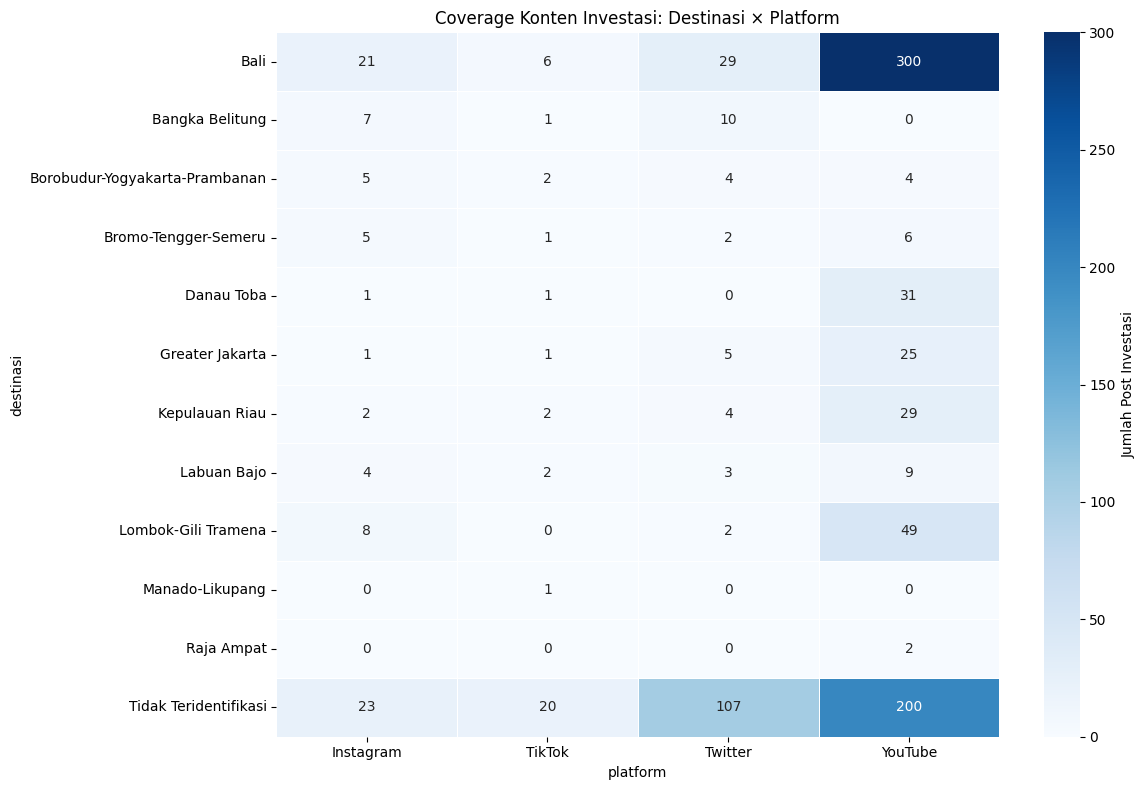

Platform diversity per destinasi (konten investasi):


,destinasi,platform_diversity
0,Bali,4
1,Borobudur-Yogyakarta-Prambanan,4
2,Bromo-Tengger-Semeru,4
3,Greater Jakarta,4
4,Labuan Bajo,4
5,Kepulauan Riau,4
6,Tidak Teridentifikasi,4
7,Bangka Belitung,3
8,Danau Toba,3
9,Lombok-Gili Tramena,3


In [ ]:
#39
# ── Volume konten investasi per destinasi × platform ─────────────────────────
dest_platform = (
    df_dest[df_dest["is_investment_content"] == 1]
    .groupby(["destinasi_tagged", "platform"])
    .size()
    .reset_index(name="n_posts")
    .rename(columns={"destinasi_tagged": "destinasi"})
)

# Heatmap destinasi × platform
pivot_dp = dest_platform.pivot_table(
    index="destinasi", columns="platform", values="n_posts", fill_value=0
)

plt.figure(figsize=(12, 8))
sns.heatmap(pivot_dp, annot=True, fmt=".0f", cmap="Blues",
            linewidths=0.5, cbar_kws={"label": "Jumlah Post Investasi"})
plt.title("Coverage Konten Investasi: Destinasi × Platform")
plt.tight_layout()
plt.savefig("06_dest_platform_heatmap.png", dpi=150)
plt.show()

# ── Destinasi dengan platform paling beragam ──────────────────────────────────
platform_diversity = (
    df_dest[df_dest["is_investment_content"] == 1]
    .groupby("destinasi_tagged")["platform"]
    .nunique()
    .sort_values(ascending=False)
    .reset_index()
    .rename(columns={"platform": "platform_diversity", "destinasi_tagged": "destinasi"})
)
print("Platform diversity per destinasi (konten investasi):")
display(platform_diversity)

## **Platform Mix per Destinasi (mana destinasi paling banyak dicoverage platform mana)**

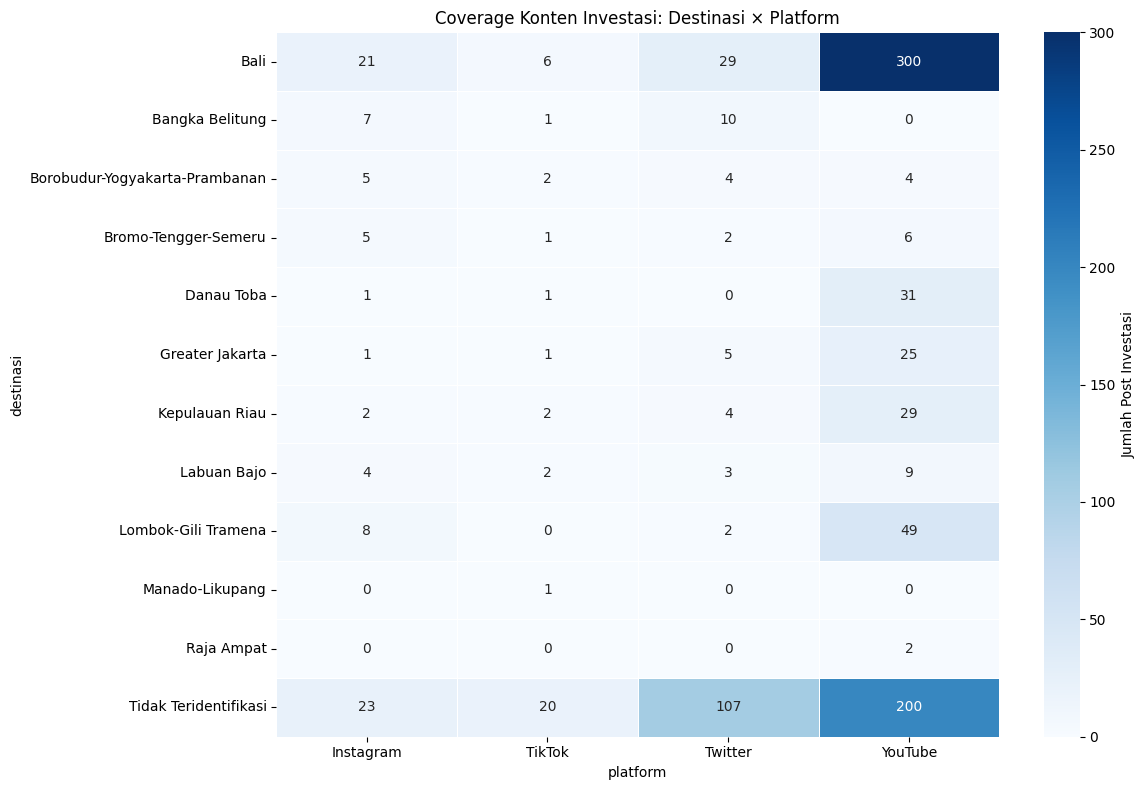

Platform diversity per destinasi (konten investasi):


,destinasi,platform_diversity
0,Bali,4
1,Borobudur-Yogyakarta-Prambanan,4
2,Bromo-Tengger-Semeru,4
3,Greater Jakarta,4
4,Labuan Bajo,4
5,Kepulauan Riau,4
6,Tidak Teridentifikasi,4
7,Bangka Belitung,3
8,Danau Toba,3
9,Lombok-Gili Tramena,3


In [ ]:
#41
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

# ── Volume konten investasi per destinasi × platform ─────────────────────────
dest_platform = (
    df_dest[df_dest["is_investment_content"] == 1]
    .groupby(["destinasi_tagged", "platform"])
    .size()
    .reset_index(name="n_posts")
    .rename(columns={"destinasi_tagged": "destinasi"})
)

# Heatmap destinasi × platform
pivot_dp = dest_platform.pivot_table(
    index="destinasi", columns="platform", values="n_posts", fill_value=0
)

plt.figure(figsize=(12, 8))
sns.heatmap(pivot_dp, annot=True, fmt=".0f", cmap="Blues",
            linewidths=0.5, cbar_kws={"label": "Jumlah Post Investasi"})
plt.title("Coverage Konten Investasi: Destinasi × Platform")
plt.tight_layout()
plt.savefig("06_dest_platform_heatmap.png", dpi=150)
plt.show()

# ── Destinasi dengan platform paling beragam ──────────────────────────────────
platform_diversity = (
    df_dest[df_dest["is_investment_content"] == 1]
    .groupby("destinasi_tagged")["platform"]
    .nunique()
    .sort_values(ascending=False)
    .reset_index()
    .rename(columns={"platform": "platform_diversity", "destinasi_tagged": "destinasi"})
)
print("Platform diversity per destinasi (konten investasi):")
display(platform_diversity)

# Pembobotan Interaksi & Uji Statistik Non-Parametrik Lintas Platform

Membuat metrik Investor_Interest_Score yang memprioritaskan tindakan krusial investor (Saves & Shares) daripada sekadar Likes, lalu membuktikannya secara ilmiah menggunakan uji Kruskal-Wallis dan Post-Hoc Mann-Whitney U.

In [ ]:
#44
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
#45
# ══════════════════════════════════════════════════════════════════════════════
# INVESTMENT GAP MATRIX (DATA NYATA: df_dest + LAKIN)
# Menggantikan cell yang sebelumnya menggunakan angka volume fiktif
# ══════════════════════════════════════════════════════════════════════════════

# ── 1. Hitung volume konten investasi dari data nyata ─────────────────────────
digital_presence = (
    df_dest[df_dest["is_investment_content"] == 1]
    .groupby("destinasi_tagged")
    .agg(
        n_posts_investasi  = ("text", "count"),
        median_engagement  = ("total_interaction", "median"),
        platform_diversity = ("platform", "nunique"),
    )
    .reset_index()
    .rename(columns={"destinasi_tagged": "destinasi"})
)

# ── 2. Gabung dengan LAKIN (capaian_pct dari tabel LAKIN nyata) ───────────────
gap_df = LAKIN_INVESTASI.merge(digital_presence, on="destinasi", how="left")
gap_df[["n_posts_investasi","median_engagement","platform_diversity"]] = \
    gap_df[["n_posts_investasi","median_engagement","platform_diversity"]].fillna(0)

# ── 3. Normalize (0-1) ────────────────────────────────────────────────────────
def normalize(series):
    mn, mx = series.min(), series.max()
    return (series - mn) / (mx - mn) if mx != mn else series * 0

gap_df["capaian_norm"]  = normalize(gap_df["capaian_pct"])
gap_df["digital_norm"]  = normalize(gap_df["n_posts_investasi"])

# ── 4. Klasifikasi kuadran ────────────────────────────────────────────────────
# Sumbu Y: capaian LAKIN (supply side — investasi aktual sudah terjadi)
# Sumbu X: volume konten digital (demand side — seberapa banyak dipromosikan)
TARGET_CAPAIAN = 100.0  # batas capaian standar LAKIN
med_digital    = gap_df["n_posts_investasi"].median()

def klasifikasi_kuadran(row):
    hi_invest  = row["capaian_pct"]       >= TARGET_CAPAIAN
    hi_digital = row["n_posts_investasi"] >= med_digital
    if hi_invest and hi_digital:
        return "Q1: Mature & Well-Promoted"
    elif hi_invest and not hi_digital:
        return "Q2: Mature & Under-Promoted ← Prioritas Kampanye"
    elif not hi_invest and hi_digital:
        return "Q3: Over-Promoted / Underperform"
    else:
        return "Q4: Hidden Gem / Needs Push"

gap_df["kuadran"] = gap_df.apply(klasifikasi_kuadran, axis=1)
gap_df["promotion_gap"] = gap_df["capaian_norm"] - gap_df["digital_norm"]

print("📊 Investment Gap Matrix — Semua data dari LAKIN + scraping nyata:")
display(gap_df[["destinasi","realisasi_juta_rp","capaian_pct","n_posts_investasi",
                "platform_diversity","kuadran","promotion_gap"]].round(3))

# ── 5. Scatter plot kuadran ───────────────────────────────────────────────────
KUADRAN_COLORS = {
    "Q1: Mature & Well-Promoted"              : "#2ecc71",
    "Q2: Mature & Under-Promoted ← Prioritas Kampanye" : "#0A66C2",
    "Q3: Over-Promoted / Underperform"        : "#e74c3c",
    "Q4: Hidden Gem / Needs Push"             : "#f39c12",
}

fig = px.scatter(
    gap_df,
    x="n_posts_investasi",
    y="capaian_pct",
    color="kuadran",
    color_discrete_map=KUADRAN_COLORS,
    text="destinasi",
    size="realisasi_juta_rp",
    size_max=50,
    hover_data=["realisasi_juta_rp","capaian_pct","n_posts_investasi","platform_diversity"],
    title=(
        "<b>Investment Gap Matrix: Realisasi Investasi (LAKIN) vs Promosi Digital</b>"
        "<br><sup>Sumbu Y = capaian target LAKIN aktual | Sumbu X = jumlah post investasi dari scraping</sup>"
    ),
    labels={
        "n_posts_investasi" : "Digital Presence (Jumlah Post Investasi dari Scraping)",
        "capaian_pct"       : "Realisasi Target Investasi — LAKIN 2025 (%)",
        "kuadran"           : "Kuadran",
    },
    template="plotly_white"
)

fig.add_hline(y=TARGET_CAPAIAN, line_dash="dash", line_color="#c0392b",
              annotation_text="Target 100% LAKIN", annotation_position="right")
fig.add_vline(x=med_digital, line_dash="dash", line_color="#7f8c8d",
              annotation_text="Median digital presence", annotation_position="top")

fig.update_traces(textposition="top center", textfont_size=10)
fig.update_layout(height=600, legend=dict(orientation="h", y=-0.2))
fig.show()

# ── 6. Promotion Gap Score bar ────────────────────────────────────────────────
fig2 = px.bar(
    gap_df.sort_values("promotion_gap", ascending=False),
    x="destinasi", y="promotion_gap",
    color="promotion_gap",
    color_continuous_scale="RdYlGn_r",
    title=(
        "<b>Promotion Gap Score per Destinasi</b>"
        "<br><sup>Positif = under-promoted (realisasi investasi tinggi tapi minim konten) | "
        "Negatif = over-hyped (banyak konten tapi realisasi rendah)</sup>"
    ),
    labels={"promotion_gap": "Promotion Gap Score", "destinasi": "Destinasi"},
    template="plotly_white"
)
fig2.update_xaxes(tickangle=30)
fig2.show()

📊 Investment Gap Matrix — Semua data dari LAKIN + scraping nyata:


,destinasi,realisasi_juta_rp,capaian_pct,n_posts_investasi,platform_diversity,kuadran,promotion_gap
0,Bali,16052380.42,138.52,356.0,4.0,Q1: Mature & Well-Promoted,-0.751
1,Greater Jakarta,23744721.75,146.21,32.0,4.0,Q1: Mature & Well-Promoted,0.176
2,Kepulauan Riau,2011716.61,130.78,37.0,4.0,Q1: Mature & Well-Promoted,0.128
3,Borobudur-Yogyakarta-Prambanan,1363228.87,169.08,15.0,4.0,Q2: Mature & Under-Promoted ← Prioritas Kampanye,0.273
4,Labuan Bajo,1741446.85,483.20,18.0,4.0,Q1: Mature & Well-Promoted,0.949
5,Danau Toba,43180.55,24.21,33.0,3.0,Q3: Over-Promoted / Underperform,-0.093
6,Lombok-Gili Tramena,4324513.54,120.24,59.0,3.0,Q1: Mature & Well-Promoted,0.043
7,Manado-Likupang,442682.56,167.81,1.0,1.0,Q2: Mature & Under-Promoted ← Prioritas Kampanye,0.310
8,Bangka Belitung,113770.57,133.13,18.0,3.0,Q1: Mature & Well-Promoted,0.187
9,Raja Ampat,81815.43,275.26,2.0,1.0,Q2: Mature & Under-Promoted ← Prioritas Kampanye,0.541


In [ ]:
#46
# ══════════════════════════════════════════════════════════════════════════════
# CHOROPLETH MAP INDONESIA: CAPAIAN INVESTASI PER DESTINASI (DATA LAKIN)
# ══════════════════════════════════════════════════════════════════════════════
import json
import urllib.request

# Konversi realisasi dari juta Rp → triliun Rp (dari LAKIN_INVESTASI yang sudah ada)
# Ini data nyata, bukan simulasi
df_map_lakin = LAKIN_INVESTASI.copy()
df_map_lakin["realisasi_triliun"] = (df_map_lakin["realisasi_juta_rp"] / 1_000_000).round(2)

# Mapping destinasi → nama provinsi (untuk match GeoJSON)
DEST_TO_PROVINSI = {
    "Bali"                           : "BALI",
    "Labuan Bajo"                    : "NUSA TENGGARA TIMUR",
    "Raja Ampat"                     : "PAPUA BARAT",
    "Danau Toba"                     : "SUMATERA UTARA",
    "Manado-Likupang"                : "SULAWESI UTARA",
    "Lombok-Gili Tramena"            : "NUSA TENGGARA BARAT",
    "Borobudur-Yogyakarta-Prambanan" : "DAERAH ISTIMEWA YOGYAKARTA",
    "Greater Jakarta"                : "DKI JAKARTA",
    "Kepulauan Riau"                 : "KEPULAUAN RIAU",
    "Bromo-Tengger-Semeru"           : "JAWA TIMUR",
    "Wakatobi"                       : "SULAWESI TENGGARA",
    "Bangka Belitung"                : "KEPULAUAN BANGKA BELITUNG",
    "Morotai"                        : "MALUKU UTARA",
}
df_map_lakin["provinsi"] = df_map_lakin["destinasi"].map(DEST_TO_PROVINSI)

# Load GeoJSON provinsi Indonesia
url_geojson = "https://raw.githubusercontent.com/superpikar/indonesia-geojson/master/indonesia-province-simple.json"
try:
    with urllib.request.urlopen(url_geojson, timeout=10) as url:
        indonesia_geo = json.loads(url.read())

    fig_map = px.choropleth_mapbox(
        df_map_lakin,
        geojson=indonesia_geo,
        locations="provinsi",
        featureidkey="properties.Propinsi",
        color="capaian_pct",
        color_continuous_scale="RdYlGn",
        mapbox_style="carto-positron",
        zoom=3.5,
        center={"lat": -2.5, "lon": 118.0},
        hover_name="destinasi",
        hover_data={
            "provinsi"         : False,
            "realisasi_triliun": True,
            "capaian_pct"      : True,
            "status_capaian"   : True,
        },
        title="<b>Peta Capaian Realisasi Investasi Pariwisata per Destinasi (LAKIN 2025)</b>",
        labels={
            "realisasi_triliun" : "Realisasi (Triliun Rp)",
            "capaian_pct"       : "Capaian Target (%)",
            "status_capaian"    : "Status",
        }
    )
    fig_map.update_layout(margin={"r":0,"t":50,"l":0,"b":0},
                          coloraxis_colorbar=dict(title="Capaian (%)"))
    fig_map.show()

except Exception as e:
    print(f"GeoJSON tidak bisa dimuat: {e}")
    # Fallback: bar chart biasa
    fig_fallback = px.bar(
        df_map_lakin.sort_values("capaian_pct"),
        x="capaian_pct", y="destinasi",
        color="status_capaian",
        orientation="h",
        title="Capaian Realisasi Investasi per Destinasi (LAKIN 2025)",
        labels={"capaian_pct": "Capaian (%)", "destinasi": "Destinasi"},
        template="plotly_white"
    )
    fig_fallback.add_vline(x=100, line_dash="dash", line_color="red",
                           annotation_text="Target 100%")
    fig_fallback.show()

print("\nSumber: LAKIN 2025 Kemenpar, Tabel 3.9")
print(df_map_lakin[["destinasi","realisasi_triliun","capaian_pct","status_capaian"]].to_string(index=False))


Sumber: LAKIN 2025 Kemenpar, Tabel 3.9
                     destinasi  realisasi_triliun  capaian_pct           status_capaian
                          Bali              16.05       138.52      Tercapai (100–149%)
               Greater Jakarta              23.74       146.21      Tercapai (100–149%)
                Kepulauan Riau               2.01       130.78      Tercapai (100–149%)
Borobudur-Yogyakarta-Prambanan               1.36       169.08    Sangat Tinggi (≥150%)
                   Labuan Bajo               1.74       483.20    Sangat Tinggi (≥150%)
                    Danau Toba               0.04        24.21      Underperform (<75%)
           Lombok-Gili Tramena               4.32       120.24      Tercapai (100–149%)
               Manado-Likupang               0.44       167.81    Sangat Tinggi (≥150%)
               Bangka Belitung               0.11       133.13      Tercapai (100–149%)
                    Raja Ampat               0.08       275.26    Sangat Tinggi 

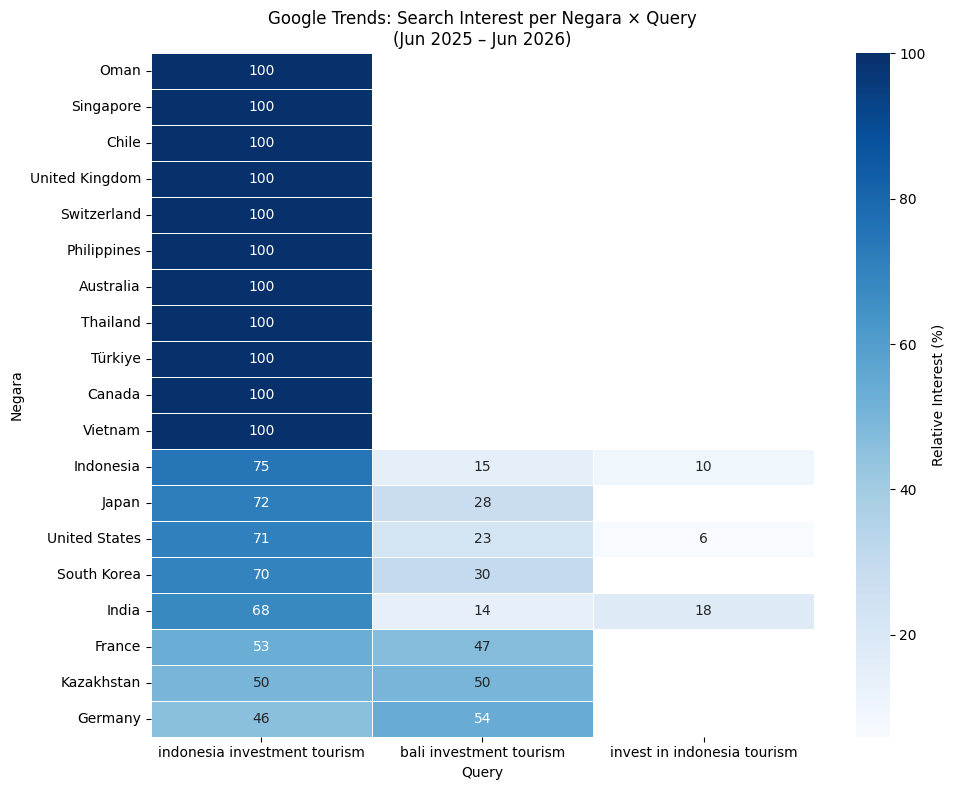

Cross-reference: Google Trends vs Data Sosmed
Negara yang muncul di Google Trends:       19
Negara yang terdeteksi di sosmed:          327
Negara ada di kedua sumber:                0 → []
Negara interest tinggi tapi TIDAK di sosmed: 19 → ['Australia', 'Canada', 'Chile', 'France', 'Germany', 'India', 'Indonesia', 'Japan', 'Kazakhstan', 'Oman', 'Philippines', 'Singapore', 'South Korea', 'Switzerland', 'Thailand', 'Türkiye', 'United Kingdom', 'United States', 'Vietnam']

→ Implikasi: negara di kolom terakhir adalah audiens potensial yang
  belum terjangkau konten sosmed yang ada di dataset kamu.


In [ ]:
#47
# ══════════════════════════════════════════════════════════════════════════════
# EXECUTIVE DASHBOARD: GLOBAL INVESTOR GEOGRAPHY (DATA NYATA: GOOGLE TRENDS)
# Menggantikan cell yang sebelumnya menggunakan angka KPI, benchmark, dan
# geo interest fiktif (Singapore EDB, Dubai DET, SoV 18.5%, dll.)
# ══════════════════════════════════════════════════════════════════════════════

# ── 1. Load Google Trends geo data (sudah diproses di Cell 27B) ───────────────
# df_geo_active sudah tersedia dari Cell 27B
# Pastikan cell 27B sudah dijalankan sebelum ini

# ── 2. Choropleth: Composite Interest Score ───────────────────────────────────
fig_geo = px.choropleth(
    df_geo_active,
    locations="country",
    locationmode="country names",
    color="composite_score",
    hover_name="country",
    hover_data={
        "q_id_invest_tourism" : True,
        "q_bali_invest"       : True,
        "q_invest_in_id"      : True,
        "dominant_query"      : True,
    },
    color_continuous_scale="Blues",
    title=(
        "<b>Global Search Interest: Investasi Pariwisata Indonesia</b>"
        "<br><sup>Sumber: Google Trends | 3 query | Jun 2025–Jun 2026 | "
        "Score = relative interest (max negara = 100)</sup>"
    ),
    labels={"composite_score": "Composite Interest Score"},
    template="plotly_white"
)
fig_geo.update_layout(geo=dict(showcoastlines=True, projection_type="natural earth"))
fig_geo.show()

# ── 3. Heatmap: negara × query breakdown ─────────────────────────────────────
pivot_trends = df_geo_active.set_index("country")[
    ["q_id_invest_tourism", "q_bali_invest", "q_invest_in_id"]
].rename(columns={
    "q_id_invest_tourism" : "indonesia investment tourism",
    "q_bali_invest"       : "bali investment tourism",
    "q_invest_in_id"      : "invest in indonesia tourism",
}).sort_values("indonesia investment tourism", ascending=False)

plt.figure(figsize=(10, 8))
sns.heatmap(
    pivot_trends,
    annot=True, fmt=".0f",
    cmap="Blues",
    linewidths=0.5,
    cbar_kws={"label": "Relative Interest (%)"},
    mask=pivot_trends.isna()
)
plt.title("Google Trends: Search Interest per Negara × Query\n(Jun 2025 – Jun 2026)")
plt.xlabel("Query")
plt.ylabel("Negara")
plt.tight_layout()
plt.savefig("07_google_trends_geo_heatmap.png", dpi=150)
plt.show()

# ── 4. Perbandingan: Bali-focused vs Indonesia-general ────────────────────────
df_focus = df_geo_active.copy()
df_focus["bali_focus"] = df_focus["q_bali_invest"].fillna(0)
df_focus["id_general"] = df_focus["q_id_invest_tourism"].fillna(0) + \
                          df_focus["q_invest_in_id"].fillna(0)
df_focus["bali_ratio"] = (
    df_focus["bali_focus"] /
    (df_focus["bali_focus"] + df_focus["id_general"]).replace(0, np.nan)
).round(3)

fig_ratio = px.bar(
    df_focus.dropna(subset=["bali_ratio"]).sort_values("bali_ratio", ascending=False),
    x="country", y="bali_ratio",
    color="bali_ratio",
    color_continuous_scale="RdYlGn_r",
    title=(
        "<b>Proporsi Pencarian 'Bali' vs 'Indonesia' per Negara</b>"
        "<br><sup>Tinggi = negara fokus ke Bali saja, bukan Indonesia secara umum. "
        "Implikasi: perlu kampanye untuk diversifikasi destinasi.</sup>"
    ),
    labels={"bali_ratio": "Proporsi Bali-focused", "country": "Negara"},
    template="plotly_white"
)
fig_ratio.add_hline(y=0.5, line_dash="dash", line_color="gray",
                    annotation_text="50% Bali / 50% Indonesia")
fig_ratio.show()

# ── 5. Cross-reference: apakah negara high-interest terwakili di data sosmed? ─
sosmed_countries = set(
    df_all["country"].dropna().str.strip().str.title().unique().tolist()
    if "country" in df_all.columns else []
)
trends_countries = set(df_geo_active["country"].tolist())

in_both    = trends_countries & sosmed_countries
trends_only = trends_countries - sosmed_countries

print("=" * 60)
print("Cross-reference: Google Trends vs Data Sosmed")
print("=" * 60)
print(f"Negara yang muncul di Google Trends:       {len(trends_countries)}")
print(f"Negara yang terdeteksi di sosmed:          {len(sosmed_countries)}")
print(f"Negara ada di kedua sumber:                {len(in_both)} → {sorted(in_both)}")
print(f"Negara interest tinggi tapi TIDAK di sosmed: {len(trends_only)} → {sorted(trends_only)}")
print("\n→ Implikasi: negara di kolom terakhir adalah audiens potensial yang")
print("  belum terjangkau konten sosmed yang ada di dataset kamu.")

In [ ]:
investment_content_by_platform = df_all[df_all['is_investment_content'] == 1].groupby('platform').size().reset_index(name='investment_posts')

total_investment_posts = investment_content_by_platform['investment_posts'].sum()
investment_content_by_platform['percentage'] = (investment_content_by_platform['investment_posts'] / total_investment_posts * 100).round(2)

print("Konten investasi (is_investment_content = 1) per platform:")
print(investment_content_by_platform.to_string(index=False))

Konten investasi (is_investment_content = 1) per platform:
 platform  investment_posts  percentage
Instagram                63        7.02
   TikTok                32        3.57
  Twitter               161       17.95
  YouTube               641       71.46
